In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet(r"C:\Users\gehan\Downloads\thesis\extracted tables\last update data\combined_df_final.parquet")

In [2]:
print(f"Shape: {df.shape}")
print(f"\nDtype summary:")
print(df.dtypes.value_counts())

Shape: (178384, 269)

Dtype summary:
int64                  81
Int8                   66
str                    63
float64                47
datetime64[us, UTC]     2
object                  2
int32                   2
category                1
Float64                 1
category                1
datetime64[us]          1
category                1
category                1
Name: count, dtype: int64


In [3]:
col_df = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(df[c].dtype) for c in df.columns],
    'null_pct': [round(df[c].isna().sum() / len(df) * 100, 1) for c in df.columns],
    'n_unique': [df[c].nunique() for c in df.columns],
    'sample': [df[c].dropna().iloc[0] if df[c].notna().any() else 'ALL NULL' for c in df.columns]
})

print(f"Total columns: {len(col_df)}\n")
print(col_df.to_string())

Total columns: 269

                                                                                                                                              column                dtype  null_pct  n_unique                                                                                                                                                                                                                                                                                                                                                                                                           sample
0                                                                                                                              metadata_booking_date                  str       0.0    176005                                                                                                                                                                                                        

In [4]:

for col in df.columns:
    if str(df[col].dtype) == 'str':
        df[col] = df[col].astype(object)
        try:
            converted = pd.to_numeric(df[col], errors='coerce')
            # Only replace if conversion is meaningful (not all NaN)
            if converted.notna().sum() > 0 and converted.notna().sum() >= df[col].notna().sum() * 0.8:
                df[col] = converted
        except Exception:
            pass


remaining_str = [c for c in df.columns if str(df[c].dtype) == 'str']
print(f"Remaining str columns: {len(remaining_str)}")
if remaining_str:
    print(remaining_str)

print("\nUpdated dtype summary:")
print(df.dtypes.value_counts())

Remaining str columns: 0

Updated dtype summary:
int64                  87
Int8                   66
float64                56
object                 50
datetime64[us, UTC]     2
int32                   2
category                1
Float64                 1
category                1
datetime64[us]          1
category                1
category                1
Name: count, dtype: int64


In [5]:

drop_cols = [
    # 100% null
    'question_on_board_the_train1_the_atmosphere_on_board',
    'question_on_board_the_train1_the_level_of_comfort_on_board',
    'question_on_board_the_train1_the_cleanliness_on_board_the_train',
    'question_on_board_the_train2_the_wi_fi_on_board',
    'total_compensation'
]


drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

print(f"Dropped: {len(drop_cols)} columns")
print(f"Remaining shape: {df.shape}")

Dropped: 0 columns
Remaining shape: (178384, 269)


In [6]:
print("Duplicate columns:", df.columns.duplicated().sum())
print(df.columns[df.columns.duplicated()].tolist())

cause_cols = [c for c in df.columns if c.startswith('cause_select_')]
print("cause_select columns:", len(cause_cols))
print("Row count:", df.shape[0])
print("Mutual exclusivity (rows summing to exactly 1):", (df[cause_cols].sum(axis=1) == 1).sum(), "/", df.shape[0])

Duplicate columns: 0
[]
cause_select columns: 22
Row count: 178384
Mutual exclusivity (rows summing to exactly 1): 178384 / 178384


In [7]:
dupe_names = df.columns[df.columns.duplicated()].unique().tolist()
print(f"{len(dupe_names)} duplicated label(s): {dupe_names}")
print(f"df shape: {df.shape}")  # sanity check vs expected ~178384 rows

for name in dupe_names:
    sub = df.loc[:, df.columns == name]
    print(f"\n{name}: {sub.shape[1]} copies")
    if sub.shape[1] == 2:
        print("  identical:", sub.iloc[:, 0].equals(sub.iloc[:, 1]))
    else:
        print("  >2 copies — inspect manually")

0 duplicated label(s): []
df shape: (178384, 269)


In [8]:
df = df.loc[:, ~df.columns.duplicated()]

In [9]:
# 1. disrup_type vs metadata_disrup: are they the same thing?
print(" disrup_type value counts")
print(df['disrup_type'].value_counts())

print("\n metadata_disrup value counts ")
print(df['metadata_disrup'].value_counts())

# 2. PNR null pattern — is missingness random or clustered by route?
print("\n PNR null rate by route_type ")
pnr_null = df['total_pax'].isna()
print(df.groupby('route_type')['total_pax'].apply(lambda x: x.isna().mean().round(3)))

print("\n PNR null rate by departure_month ")
print(df.groupby('departure_month')['total_pax'].apply(lambda x: x.isna().mean().round(3)))

 disrup_type value counts
disrup_type
none    141310
4        12961
3         7068
5         5967
2         5522
1         3895
99        1661
Name: count, dtype: int64

 metadata_disrup value counts 
metadata_disrup
         141310
4|4        7652
4          5309
3|3        4634
2|2        3668
5|5        3609
1|1        2811
3          2434
5          2358
2          1854
99|99      1247
1          1084
99          414
Name: count, dtype: int64

 PNR null rate by route_type 
route_type
Channel        0.065
Continental    1.000
Name: total_pax, dtype: float64

 PNR null rate by departure_month 
departure_month
1     0.368
2     0.362
3     0.339
4     0.568
5     0.497
6     0.346
7     0.370
8     0.306
9     0.330
10    0.357
11    0.345
12    0.383
Name: total_pax, dtype: float64


In [10]:
# Encoding route_type as binary (Channel = 1, Continental = 0)
df['is_channel'] = (df['route_type'] == 'Channel').astype(int)

print(" is_channel distribution ")
print(df['is_channel'].value_counts())
print(f"\nChannel: {df['is_channel'].mean():.1%} of rows")

 is_channel distribution 
is_channel
1    116265
0     62119
Name: count, dtype: int64

Channel: 65.2% of rows


In [11]:
print(" Row counts by route_type ")
print(df['route_type'].value_counts())

print("\n Continental routes — which origin/destination? ")
cont = df[df['route_type'] == 'Continental']
print(cont.groupby(['metadata_origin_station', 'metadata_destination_station']).size().sort_values(ascending=False).head(15))

 Row counts by route_type 
route_type
Channel        116265
Continental     62119
Name: count, dtype: int64

 Continental routes — which origin/destination? 
metadata_origin_station  metadata_destination_station
Brussels Midi / Zuid     Paris Gare du Nord              11325
Paris Gare du Nord       Brussels Midi / Zuid            11086
                         Amsterdam Centraal               5479
Amsterdam Centraal       Paris Gare du Nord               5179
Cologne Hbf              Paris Gare du Nord               3959
Rotterdam Centraal       Paris Gare du Nord               3780
Paris Gare du Nord       Cologne Hbf                      2937
                         Rotterdam Centraal               2710
Amsterdam Centraal       Brussels Midi / Zuid             1134
Schiphol Airport         Paris Gare du Nord               1133
Liege-Guillemins         Paris Gare du Nord               1070
Brussels Midi / Zuid     Amsterdam Centraal                957
Paris Gare du Nord       Liege-G

In [12]:
# NPS distribution by route type
print(" NPS mean and distribution by route_type")
print(df.groupby('route_type')['question_recommendation_nps_a'].agg(['mean','median','std','count']).round(2))

print("\n NPS group split by route_type ")
print(df.groupby(['route_type','question_recommendation_nps_a_nps_group']).size().unstack().assign(
    pct_promoter=lambda x: (x['Promoter'] / x.sum(axis=1) * 100).round(1),
    pct_detractor=lambda x: (x['Detractor'] / x.sum(axis=1) * 100).round(1),
))

# Delay profile by route type
print("\n Delay profile by route_type ")
print(df.groupby('route_type')['arrival_delay_minute'].agg(['mean','median',
    lambda x: (x > 0).mean().round(3),
    lambda x: (x > 15).mean().round(3),
    lambda x: (x > 30).mean().round(3),
]).rename(columns={'<lambda_0>':'pct_any_delay',
                   '<lambda_1>':'pct_gt15',
                   '<lambda_2>':'pct_gt30'}))

# Class of service mix
print("\n Class of service by route_type ")
print(df.groupby(['route_type','metadata_class_of_service']).size().unstack(fill_value=0))

# Trip purpose mix
print("\n Trip purpose by route_type ")
print(df.groupby(['route_type','question_main_trip_purpose']).size().unstack(fill_value=0))

 NPS mean and distribution by route_type
             mean  median   std   count
route_type                             
Channel      8.24     9.0  2.08  116265
Continental  7.75     8.0  2.34   62119

 NPS group split by route_type 
question_recommendation_nps_a_nps_group  Detractor  Passive  Promoter  \
route_type                                                              
Channel                                      16749    36317     63199   
Continental                                  12872    21513     27734   

question_recommendation_nps_a_nps_group  pct_promoter  pct_detractor  
route_type                                                            
Channel                                          54.4           14.4  
Continental                                      44.6           20.7  

 Delay profile by route_type 
                  mean  median  pct_any_delay  pct_gt15  pct_gt30
route_type                                                       
Channel       9.693201    

 NPS summary
N              : 178,384
Detractors     : 29,621 (16.6%)
Passives       : 57,830 (32.4%)
Promoters      : 90,933 (51.0%)
NPS Score      : 34.4

Mean           : 8.07
Median         : 9.0
Std            : 2.18

Value counts:
question_recommendation_nps_a
0.0      2794
1.0      1563
2.0      2375
3.0      2939
4.0      2944
5.0      7939
6.0      9067
7.0     19378
8.0     38452
9.0     33299
10.0    57634
Name: count, dtype: int64


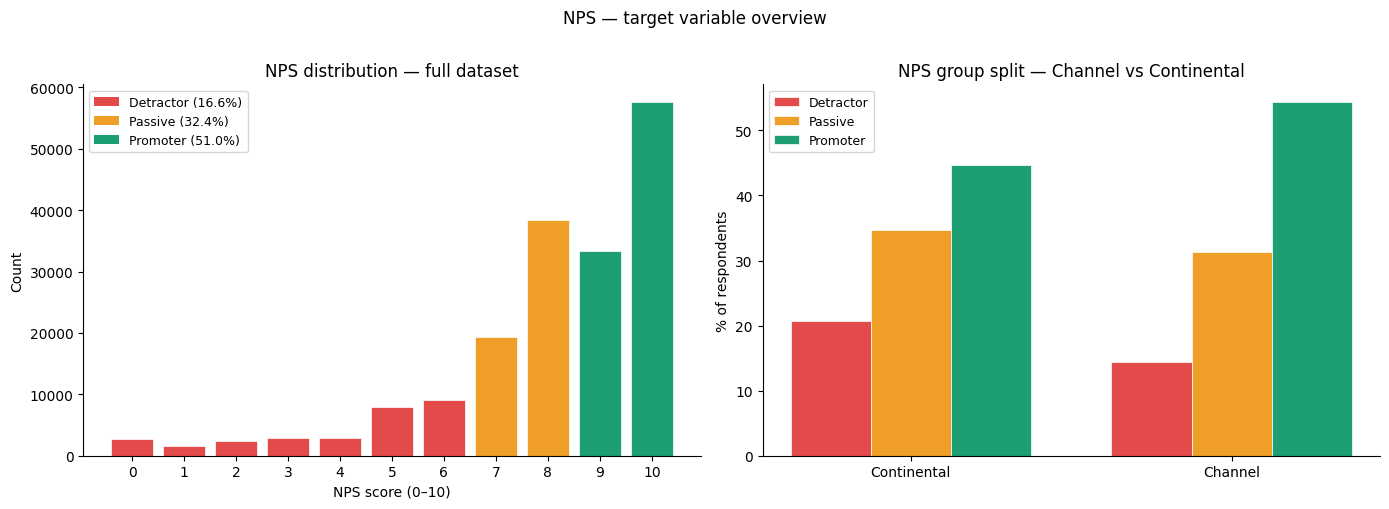

In [13]:

from pathlib import Path

OUTPUT_DIR = Path(r"C:\Users\gehan\Downloads\thesis\extracted tables\last update data\eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NPS = df['question_recommendation_nps_a']
n = len(df)


det = (NPS <= 6).sum()
pas = ((NPS >= 7) & (NPS <= 8)).sum()
pro = (NPS >= 9).sum()
nps_score = (pro - det) / n * 100

print(" NPS summary")
print(f"N              : {n:,}")
print(f"Detractors     : {det:,} ({det/n*100:.1f}%)")
print(f"Passives       : {pas:,} ({pas/n*100:.1f}%)")
print(f"Promoters      : {pro:,} ({pro/n*100:.1f}%)")
print(f"NPS Score      : {nps_score:.1f}")
print(f"\nMean           : {NPS.mean():.2f}")
print(f"Median         : {NPS.median():.1f}")
print(f"Std            : {NPS.std():.2f}")
print(f"\nValue counts:")
print(NPS.value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


colors = {0:'#E24B4A',1:'#E24B4A',2:'#E24B4A',3:'#E24B4A',4:'#E24B4A',
          5:'#E24B4A',6:'#E24B4A',7:'#EF9F27',8:'#EF9F27',
          9:'#1D9E75',10:'#1D9E75'}
counts = NPS.value_counts().sort_index()
axes[0].bar(counts.index, counts.values,
            color=[colors[i] for i in counts.index], edgecolor='white', lw=0.5)
axes[0].set_xlabel('NPS score (0–10)')
axes[0].set_ylabel('Count')
axes[0].set_title('NPS distribution — full dataset')
axes[0].set_xticks(range(11))
for s in ['top','right']: axes[0].spines[s].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E24B4A', label=f'Detractor ({det/n*100:.1f}%)'),
                   Patch(facecolor='#EF9F27', label=f'Passive ({pas/n*100:.1f}%)'),
                   Patch(facecolor='#1D9E75', label=f'Promoter ({pro/n*100:.1f}%)')]
axes[0].legend(handles=legend_elements, fontsize=9)

route_nps = df.groupby(['is_channel','question_recommendation_nps_a_nps_group']).size().unstack()
route_nps_pct = route_nps.div(route_nps.sum(axis=1), axis=0) * 100
route_nps_pct.index = ['Continental','Channel']
route_nps_pct = route_nps_pct[['Detractor','Passive','Promoter']]

x = np.arange(2)
width = 0.25
grp_colors = ['#E24B4A','#EF9F27','#1D9E75']
for i, (grp, col) in enumerate(zip(['Detractor','Passive','Promoter'], grp_colors)):
    axes[1].bar(x + i*width, route_nps_pct[grp], width, label=grp, color=col, edgecolor='white', lw=0.5)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['Continental','Channel'])
axes[1].set_ylabel('% of respondents')
axes[1].set_title('NPS group split — Channel vs Continental')
axes[1].legend(fontsize=9)
for s in ['top','right']: axes[1].spines[s].set_visible(False)

plt.suptitle('NPS — target variable overview', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_nps_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:

delay = df['arrival_delay_minute']

print(" Arrival delay summary ")
print(f"N total        : {len(delay):,}")
print(f"N zero (on time): {(delay == 0).sum():,} ({(delay == 0).mean()*100:.1f}%)")
print(f"N early        : {(delay < 0).sum():,} ({(delay < 0).mean()*100:.1f}%)")
print(f"N any delay    : {(delay > 0).sum():,} ({(delay > 0).mean()*100:.1f}%)")
print(f"\nAmong delayed only:")
delayed = delay[delay > 0]
print(f"  Mean         : {delayed.mean():.1f} min")
print(f"  Median       : {delayed.median():.1f} min")
print(f"  90th pct     : {delayed.quantile(0.90):.1f} min")
print(f"  99th pct     : {delayed.quantile(0.99):.1f} min")
print(f"  Max          : {delayed.max():.1f} min")

print(f"\n Threshold breach rates ")
for thresh in [5, 15, 30, 60]:
    col = f'delay_gt{thresh}'
    print(f"  >={thresh} min : {df[col].sum():,} ({df[col].mean()*100:.1f}%)")

print(f"\n Delay bucket distribution ")
print(df['delay_bucket'].value_counts().sort_index())

print(f"\n Delay profile by route_type ")
print(df.groupby('route_type')['arrival_delay_minute'].agg(
    n='count',
    pct_on_time=lambda x: (x == 0).mean().round(3),
    pct_early=lambda x: (x < 0).mean().round(3),
    mean_delay=lambda x: x[x > 0].mean().round(1),
    pct_gt15=lambda x: (x > 15).mean().round(3),
    pct_gt30=lambda x: (x > 30).mean().round(3),
    pct_gt60=lambda x: (x > 60).mean().round(3),
))

 Arrival delay summary 
N total        : 178,384
N zero (on time): 35,907 (20.1%)
N early        : 34,374 (19.3%)
N any delay    : 108,103 (60.6%)

Among delayed only:
  Mean         : 21.1 min
  Median       : 8.0 min
  90th pct     : 56.0 min
  99th pct     : 166.0 min
  Max          : 739.0 min

 Threshold breach rates 
  >=5 min : 66,438 (37.2%)
  >=15 min : 40,908 (22.9%)
  >=30 min : 23,574 (13.2%)
  >=60 min : 9,769 (5.5%)

 Delay bucket distribution 
delay_bucket
Early        34374
On time      35907
1-5 min      46769
6-15 min     21679
16-30 min    17101
31-60 min    13116
>60 min       9438
Name: count, dtype: int64

 Delay profile by route_type 
                  n  pct_on_time  pct_early  mean_delay  pct_gt15  pct_gt30  \
route_type                                                                    
Channel      116265        0.148      0.293        19.0     0.181     0.100   
Continental   62119        0.302      0.005        24.3     0.299     0.176   

             pct_

In [15]:

print(" Threshold boundary check ")
for thresh in [5, 15, 30, 60]:
    col = f'delay_gt{thresh}'
  
    at_boundary = df[df['arrival_delay_clipped'] == thresh]['arrival_delay_clipped'].count()
    just_below = df[df['arrival_delay_clipped'] == thresh - 1]['arrival_delay_clipped'].count()
    in_dummy = df[df['arrival_delay_clipped'] == thresh][col].iloc[0] if at_boundary > 0 else 'N/A'
    print(f"  thresh={thresh}: rows at exactly {thresh}min = {at_boundary:,}, "
          f"rows at {thresh-1}min = {just_below:,}, "
          f"dummy value at exactly {thresh}min = {in_dummy}")


print(f"\n Early arrivals in delay_gt5 ")
print(f"  Rows where arrived_early=1 and delay_gt5=0: "
      f"{((df['arrived_early']==1) & (df['delay_gt5']==0)).sum():,}")
print(f"  Rows where arrived_early=1 and delay_gt5=1: "
      f"{((df['arrived_early']==1) & (df['delay_gt5']==1)).sum():,}")

 Threshold boundary check 
  thresh=5: rows at exactly 5min = 5,104, rows at 4min = 6,551, dummy value at exactly 5min = 1
  thresh=15: rows at exactly 15min = 1,253, rows at 14min = 1,497, dummy value at exactly 15min = 1
  thresh=30: rows at exactly 30min = 1,020, rows at 29min = 1,049, dummy value at exactly 30min = 1
  thresh=60: rows at exactly 60min = 331, rows at 59min = 376, dummy value at exactly 60min = 1

 Early arrivals in delay_gt5 
  Rows where arrived_early=1 and delay_gt5=0: 34,374
  Rows where arrived_early=1 and delay_gt5=1: 0


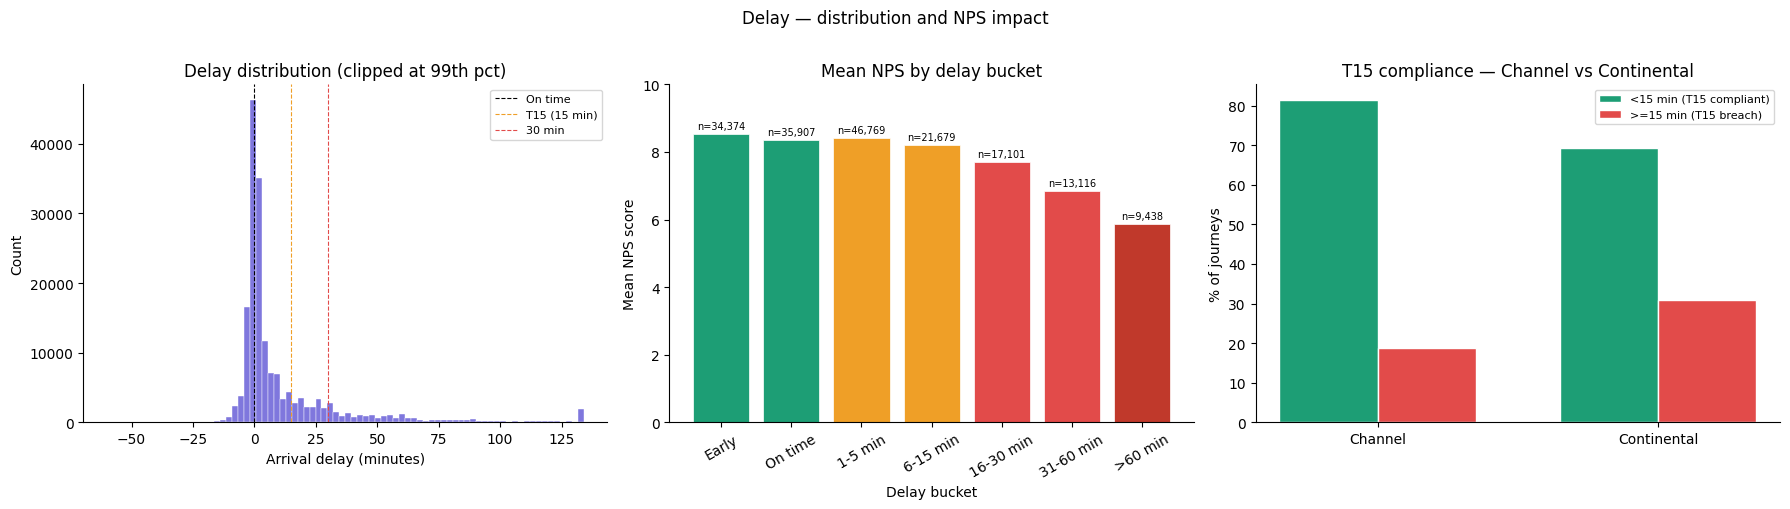

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


clip_val = df['arrival_delay_minute'].quantile(0.99)
plot_delay = df['arrival_delay_minute'].clip(-60, clip_val)
axes[0].hist(plot_delay, bins=80, color='#7F77DD', edgecolor='white', lw=0.3)
axes[0].axvline(0,  color='black',   lw=0.8, linestyle='--', label='On time')
axes[0].axvline(15, color='#EF9F27', lw=0.8, linestyle='--', label='T15 (15 min)')
axes[0].axvline(30, color='#E24B4A', lw=0.8, linestyle='--', label='30 min')
axes[0].set_xlabel('Arrival delay (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Delay distribution (clipped at 99th pct)')
axes[0].legend(fontsize=8)
for s in ['top','right']: axes[0].spines[s].set_visible(False)


bucket_nps = df.groupby('delay_bucket', observed=True)['question_recommendation_nps_a'].agg(
    mean='mean', count='count'
).reset_index()

bar_colors = ['#1D9E75','#1D9E75','#EF9F27','#EF9F27','#E24B4A','#E24B4A','#C0392B']
bars = axes[1].bar(bucket_nps['delay_bucket'].astype(str),
                   bucket_nps['mean'],
                   color=bar_colors, edgecolor='white', lw=0.5)
axes[1].set_xlabel('Delay bucket')
axes[1].set_ylabel('Mean NPS score')
axes[1].set_title('Mean NPS by delay bucket')
axes[1].set_ylim(0, 10)
axes[1].tick_params(axis='x', rotation=30)

for bar, (_, row) in zip(bars, bucket_nps.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'n={row["count"]:,}', ha='center', va='bottom', fontsize=7)
for s in ['top','right']: axes[1].spines[s].set_visible(False)


route_delay = df.groupby('route_type').agg(
    pct_on_time  = ('delay_gt15', lambda x: (x == 0).mean() * 100),
    pct_t15      = ('delay_gt15', lambda x: x.mean() * 100),
).reset_index()

x = np.arange(2)
width = 0.35
axes[2].bar(x - width/2, route_delay['pct_on_time'], width,
            label='<15 min (T15 compliant)', color='#1D9E75', edgecolor='white')
axes[2].bar(x + width/2, route_delay['pct_t15'], width,
            label='>=15 min (T15 breach)', color='#E24B4A', edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(route_delay['route_type'])
axes[2].set_ylabel('% of journeys')
axes[2].set_title('T15 compliance — Channel vs Continental')
axes[2].legend(fontsize=8)
for s in ['top','right']: axes[2].spines[s].set_visible(False)

plt.suptitle('Delay — distribution and NPS impact', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_delay_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print(" Mean NPS by delay bucket ")
bucket_stats = df.groupby('delay_bucket', observed=True)['question_recommendation_nps_a'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).round(2)
print(bucket_stats.to_string())

print("\n Mean NPS by route_type x T15 breach ")
print(df.groupby(['route_type', 'delay_gt15'])['question_recommendation_nps_a'].agg(
    n='count',
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).round(2).to_string())

print("\n=== NPS delta: T15 breach vs compliant, by route ===")
for route in ['Channel', 'Continental']:
    sub = df[df['route_type'] == route]
    nps_ok  = sub[sub['delay_gt15'] == 0]['question_recommendation_nps_a'].mean()
    nps_breach = sub[sub['delay_gt15'] == 1]['question_recommendation_nps_a'].mean()
    print(f"  {route}: compliant={nps_ok:.2f}, breach={nps_breach:.2f}, delta={nps_breach - nps_ok:.2f}")

 Mean NPS by delay bucket 
                  n  mean  median   std  pct_promoter  pct_detractor
delay_bucket                                                        
Early         34374  8.53     9.0  1.84         60.15          10.42
On time       35907  8.35     9.0  1.94         55.52          12.20
1-5 min       46769  8.40     9.0  1.89         56.48          11.42
6-15 min      21679  8.21     9.0  2.03         52.30          14.41
16-30 min     17101  7.69     8.0  2.32         42.21          21.93
31-60 min     13116  6.84     7.0  2.61         28.07          35.30
>60 min        9438  5.86     6.0  2.89         17.65          51.02

 Mean NPS by route_type x T15 breach 
                            n  mean  pct_promoter  pct_detractor
route_type  delay_gt15                                          
Channel     0           94515  8.48         58.76          10.87
            1           21750  7.20         35.25          29.75
Continental 0           42961  8.19         51.72    

In [18]:
df['delay_gt10'] = (df['arrival_delay_minute'] > 10).astype(int)

print(" Mean NPS by delay bucket ")
bucket_stats = df.groupby('delay_bucket', observed=True)['question_recommendation_nps_a'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).round(2)
print(bucket_stats.to_string())

print("\n Mean NPS by route_type x T10 breach ")
print(df.groupby(['route_type', 'delay_gt10'])['question_recommendation_nps_a'].agg(
    n='count',
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).round(2).to_string())

print("\n=== NPS delta: T10 breach vs compliant, by route ===")
for route in ['Channel', 'Continental']:
    sub = df[df['route_type'] == route]
    nps_ok  = sub[sub['delay_gt10'] == 0]['question_recommendation_nps_a'].mean()
    nps_breach = sub[sub['delay_gt10'] == 1]['question_recommendation_nps_a'].mean()
    print(f"  {route}: compliant={nps_ok:.2f}, breach={nps_breach:.2f}, delta={nps_breach - nps_ok:.2f}")

 Mean NPS by delay bucket 
                  n  mean  median   std  pct_promoter  pct_detractor
delay_bucket                                                        
Early         34374  8.53     9.0  1.84         60.15          10.42
On time       35907  8.35     9.0  1.94         55.52          12.20
1-5 min       46769  8.40     9.0  1.89         56.48          11.42
6-15 min      21679  8.21     9.0  2.03         52.30          14.41
16-30 min     17101  7.69     8.0  2.32         42.21          21.93
31-60 min     13116  6.84     7.0  2.61         28.07          35.30
>60 min        9438  5.86     6.0  2.89         17.65          51.02

 Mean NPS by route_type x T10 breach 
                            n  mean  pct_promoter  pct_detractor
route_type  delay_gt10                                          
Channel     0           91469  8.49         58.96          10.75
            1           24796  7.33         37.39          27.89
Continental 0           39596  8.20         52.19    

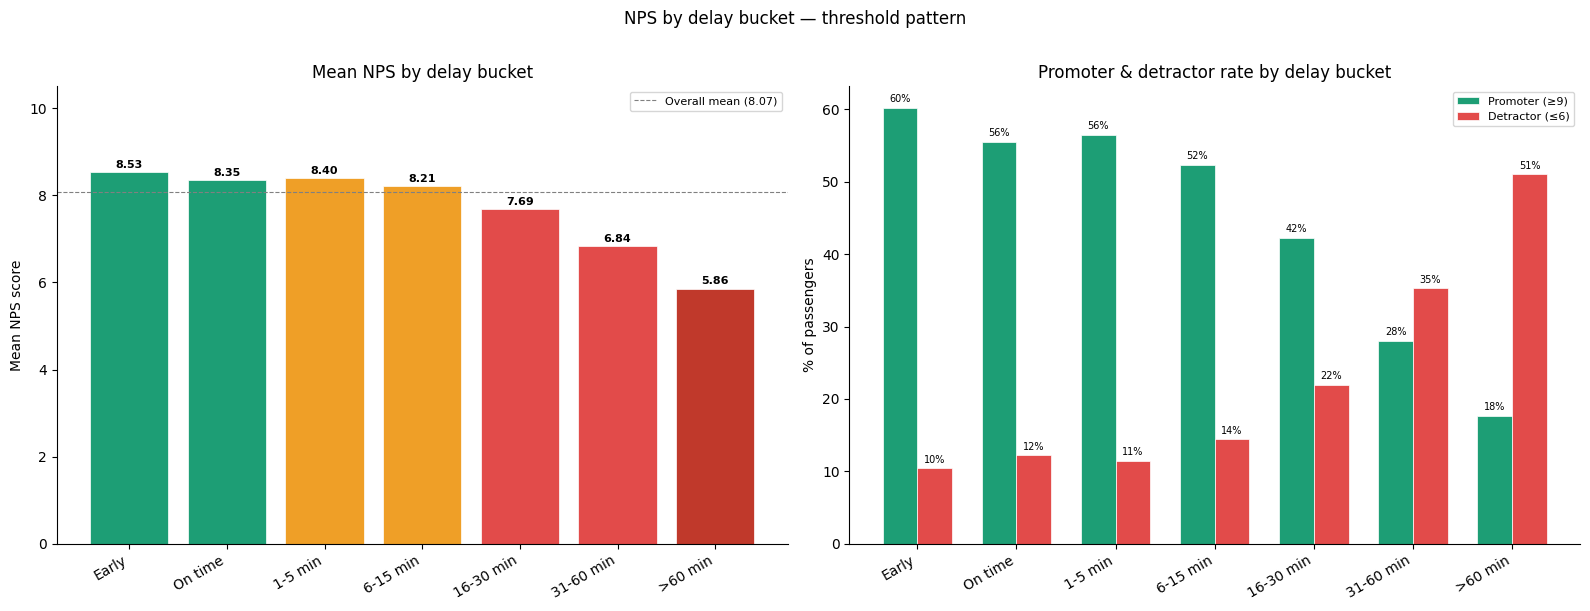

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

buckets = bucket_stats.index.astype(str)
x = np.arange(len(buckets))


ax = axes[0]
bars = ax.bar(x, bucket_stats['mean'], color=[
    '#1D9E75','#1D9E75','#EF9F27','#EF9F27','#E24B4A','#E24B4A','#C0392B'
], edgecolor='white', lw=0.5, zorder=2)


for bar, val in zip(bars, bucket_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(df['question_recommendation_nps_a'].mean(), color='gray',
           linestyle='--', lw=0.8, label=f'Overall mean ({df["question_recommendation_nps_a"].mean():.2f})')
ax.set_xticks(x)
ax.set_xticklabels(buckets, rotation=30, ha='right')
ax.set_ylabel('Mean NPS score')
ax.set_title('Mean NPS by delay bucket')
ax.set_ylim(0, 10.5)
ax.legend(fontsize=8)
for s in ['top','right']: ax.spines[s].set_visible(False)


ax = axes[1]
width = 0.35
ax.bar(x - width/2, bucket_stats['pct_promoter'], width,
       label='Promoter (≥9)', color='#1D9E75', edgecolor='white', lw=0.5)
ax.bar(x + width/2, bucket_stats['pct_detractor'], width,
       label='Detractor (≤6)', color='#E24B4A', edgecolor='white', lw=0.5)


for i, (pro, det) in enumerate(zip(bucket_stats['pct_promoter'], bucket_stats['pct_detractor'])):
    ax.text(i - width/2, pro + 0.5, f'{pro:.0f}%', ha='center', va='bottom', fontsize=7)
    ax.text(i + width/2, det + 0.5, f'{det:.0f}%', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(buckets, rotation=30, ha='right')
ax.set_ylabel('% of passengers')
ax.set_title('Promoter & detractor rate by delay bucket')
ax.legend(fontsize=8)
for s in ['top','right']: ax.spines[s].set_visible(False)

plt.suptitle('NPS by delay bucket — threshold pattern', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_nps_by_delay_bucket.png', dpi=150, bbox_inches='tight')
plt.show()

## Delay cause distribution

In [20]:

print("Delay cause group distribution ")
cause_counts = df['delay_cause_group'].value_counts()
print(cause_counts)
print(f"\nAs % of all journeys:")
print((cause_counts / len(df) * 100).round(1))

print("\n Internal vs External split (delayed services only) ")
delayed = df[df['arrival_delay_minute'] >= 15]
print(f"Delayed services (>=15 min): {len(delayed):,}")
print(delayed['delay_is_internal'].value_counts())
print(f"\nInternal: {delayed['delay_is_internal'].mean():.1%}")
print(f"External: {delayed['delay_is_external'].mean():.1%}")
print(f"Unknown/No cause: {(1 - delayed['delay_is_internal'] - delayed['delay_is_external']).clip(0).mean():.1%}")

print("\n Mean NPS by delay cause group ")
cause_nps = df.groupby('delay_cause_group')['question_recommendation_nps_a'].agg(
    n='count',
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).round(2).sort_values('mean')
print(cause_nps.to_string())

print("\n Mean delay (minutes) by cause group (delayed only) ")
print(df[df['arrival_delay_minute'] > 0].groupby('delay_cause_group')['arrival_delay_minute'].agg(
    n='count', mean='mean', median='median', p90=lambda x: x.quantile(0.9)
).round(1).sort_values('mean', ascending=False).to_string())

Delay cause group distribution 
delay_cause_group
No_Delay               68932
Traffic_Regulation     58418
Passenger_Related      19630
Infrastructure         10924
Rolling_Stock          10456
Eurostar_Operations     6071
Weather_Safety          3860
Unknown                   93
Name: count, dtype: int64

As % of all journeys:
delay_cause_group
No_Delay               38.6
Traffic_Regulation     32.7
Passenger_Related      11.0
Infrastructure          6.1
Rolling_Stock           5.9
Eurostar_Operations     3.4
Weather_Safety          2.2
Unknown                 0.1
Name: count, dtype: float64

 Internal vs External split (delayed services only) 
Delayed services (>=15 min): 40,908
delay_is_internal
0    27247
1    13661
Name: count, dtype: int64

Internal: 33.4%
External: 53.5%
Unknown/No cause: 13.1%

 Mean NPS by delay cause group 
                         n  mean  pct_promoter  pct_detractor
delay_cause_group                                            
Rolling_Stock        10456  7

In [21]:

print(" Delay cause select distribution ")
select_counts = df['delay_cause_select'].value_counts()
print(select_counts)
print(f"\nAs % of all journeys:")
print((select_counts / len(df) * 100).round(1))

print("\n Responsibility split by selective cause ")
print(df.groupby('delay_cause_select')['delay_cause_responsibility']
        .value_counts(normalize=True, dropna=False).unstack().round(3))

print("\n Mean NPS by selective cause ")
select_nps = df.groupby('delay_cause_select')['question_recommendation_nps_a'].agg(
    n='count',
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).round(2).sort_values('mean')
print(select_nps.to_string())

print("\n Mean delay (minutes) by selective cause (delayed only) ")
print(df[df['arrival_delay_minute'] > 0].groupby('delay_cause_select')['arrival_delay_minute'].agg(
    n='count', mean='mean', median='median', p90=lambda x: x.quantile(0.9)
).round(1).sort_values('mean', ascending=False).to_string())

 Delay cause select distribution 
delay_cause_select
No_Delay                      68932
I6_TrafficReg                 57827
I4_InfraFault                  8865
M1_Reliability                 7905
S1_Passengers                  5703
I5_TrainsIncident              5016
S2_Congestion                  3982
Weather_Safety                 3860
I2_People                      3399
O1_Driving                     2005
I3_InfraWorks                  1939
I1_Animals                     1530
M3_TrainsetShortage            1391
M2_DepotRelease                1126
O4_OCC                         1063
S4_TerminalStaff                999
A4_LostPathway                  591
O2_TrainManager                 573
K1_Catering                     547
Other_rare_within_expanded      526
O3_Planning                     512
Unknown                          93
Name: count, dtype: int64

As % of all journeys:
delay_cause_select
No_Delay                      38.6
I6_TrafficReg                 32.4
I4_InfraFault    

In [22]:
no_delay = df[df['delay_cause_select'] == 'No_Delay']
has_delay = no_delay['arrival_delay_minute'] > 0
print(f"No_Delay rows with positive arrival_delay_minute: {has_delay.sum():,} of {len(no_delay):,} ({has_delay.mean():.1%})")
print(no_delay.loc[has_delay, 'arrival_delay_minute'].describe().round(1))
print("\nNPS — true zero delay vs delayed-but-uncaused:")
print(no_delay.groupby(has_delay)['question_recommendation_nps_a'].agg(n='count', mean='mean').round(2))

No_Delay rows with positive arrival_delay_minute: 11,023 of 68,932 (16.0%)
count    11023.0
mean        23.9
std         36.7
min          1.0
25%          2.0
50%          8.0
75%         31.0
max        319.0
Name: arrival_delay_minute, dtype: float64

NPS — true zero delay vs delayed-but-uncaused:
                          n  mean
arrival_delay_minute             
False                 57909  8.49
True                  11023  7.62


In [23]:

mask = (df['delay_cause_select'] == 'No_Delay') & (df['arrival_delay_minute'] > 0)
print(f"Reclassifying {mask.sum():,} rows")

df.loc[mask, 'delay_cause_select'] = 'Delayed_NoCauseRecord'


old_dummy_cols = [c for c in df.columns if c.startswith('cause_select_')]
df = df.drop(columns=old_dummy_cols)

select_dummies = pd.get_dummies(df['delay_cause_select'], prefix='cause_select').astype(int)
df = pd.concat([df, select_dummies], axis=1)

print(f"\nNew dummy columns ({len(select_dummies.columns)}): {list(select_dummies.columns)}")

print("\ndelay_cause_select value counts:")
print(df['delay_cause_select'].value_counts())

print("\nNPS by cause ")
print(df.groupby('delay_cause_select')['question_recommendation_nps_a']
        .agg(n='count', mean='mean').round(2).sort_values('mean'))


select_dummy_cols = [c for c in df.columns if c.startswith('cause_select_')]
row_sums = df[select_dummy_cols].sum(axis=1)
print(f"\nRows summing to exactly 1: {(row_sums == 1).sum():,} of {len(df):,}")

Reclassifying 11,023 rows

New dummy columns (23): ['cause_select_A4_LostPathway', 'cause_select_Delayed_NoCauseRecord', 'cause_select_I1_Animals', 'cause_select_I2_People', 'cause_select_I3_InfraWorks', 'cause_select_I4_InfraFault', 'cause_select_I5_TrainsIncident', 'cause_select_I6_TrafficReg', 'cause_select_K1_Catering', 'cause_select_M1_Reliability', 'cause_select_M2_DepotRelease', 'cause_select_M3_TrainsetShortage', 'cause_select_No_Delay', 'cause_select_O1_Driving', 'cause_select_O2_TrainManager', 'cause_select_O3_Planning', 'cause_select_O4_OCC', 'cause_select_Other_rare_within_expanded', 'cause_select_S1_Passengers', 'cause_select_S2_Congestion', 'cause_select_S4_TerminalStaff', 'cause_select_Unknown', 'cause_select_Weather_Safety']

delay_cause_select value counts:
delay_cause_select
No_Delay                      57909
I6_TrafficReg                 57827
Delayed_NoCauseRecord         11023
I4_InfraFault                  8865
M1_Reliability                 7905
S1_Passengers   

In [24]:

individual_cause_map = {
    'I4 - Infrastructure Fault':                                        'I4_InfraFault',
    'I3 - Infra Works':                                                 'I3_InfraWorks',
    'I6 - Traffic Regulation':                                          'I6_TrafficReg',
    'A4 - Lost of Pathway as train running late with lost of priority':  'A4_LostPathway',
    'S1 - Passengers':                                                  'S1_Passengers',
    'S2 - Congestion':                                                  'S2_Congestion',
    'I2 - People':                                                      'I2_People',
    'I1 - Animals':                                                     'I1_Animals',
    'I5 - Trains related incidents':                                    'I5_TrainsIncident',
    'M1 - Reliability (Sets malfunctions/defects)':                     'M1_Reliability',
    'M2 - Late release from the depot':                                 'M2_DepotRelease',
    'M3 - Lack of Available Trainsets':                                 'M3_TrainsetShortage',
    'O1 - Driving':                                                     'O1_Driving',
    'O2 - Train Manager':                                               'O2_TrainManager',
    'O3 - Planning Rostering Eurostar':                                 'O3_Planning',
    'O4 - OCC (Communication issue, Error...)':                         'O4_OCC',
    'K1 - Catering':                                                    'K1_Catering',
    'S4 - Eurostar Terminal Staff & Platform duties':                   'S4_TerminalStaff',
}

tiny_in_significant = [
    'G1 -Facilities issues (Lift, BMI Fence Platform 1&2…)',
    'M4 - Cleaning',
    'A9 - Additional Operational Stop',
]

df['delay_cause_select'] = df['delay_cause_category'].map(individual_cause_map)
df.loc[df['delay_cause_category'].isin(tiny_in_significant), 'delay_cause_select'] = 'Other_rare_within_expanded'
df.loc[df['delay_cause_group'] == 'Weather_Safety', 'delay_cause_select'] = 'Weather_Safety'
df.loc[df['delay_cause_category'] == 'Unmapped', 'delay_cause_select'] = 'Unknown'
df['delay_cause_select'] = df['delay_cause_select'].fillna('No_Delay')


mask_delayed_uncaused = (df['delay_cause_select'] == 'No_Delay') & (df['arrival_delay_minute'] > 0)
df.loc[mask_delayed_uncaused, 'delay_cause_select'] = 'Delayed_NoCauseRecord'

print(df['delay_cause_select'].value_counts())
print(f"\nTotal: {df['delay_cause_select'].value_counts().sum()} (should be {len(df)})")

print("\nNPS by selective cause:")
print(df.groupby('delay_cause_select')['question_recommendation_nps_a']
        .agg(['mean', 'count']).round(2).sort_values('mean'))

select_dummies = pd.get_dummies(df['delay_cause_select'], prefix='cause_select').astype(int)
df = pd.concat([df, select_dummies], axis=1)
print(f"\nNew dummy columns added: {list(select_dummies.columns)}")

delay_cause_select
No_Delay                      57909
I6_TrafficReg                 57827
Delayed_NoCauseRecord         11023
I4_InfraFault                  8865
M1_Reliability                 7905
S1_Passengers                  5703
I5_TrainsIncident              5016
S2_Congestion                  3982
Weather_Safety                 3860
I2_People                      3399
O1_Driving                     2005
I3_InfraWorks                  1939
I1_Animals                     1530
M3_TrainsetShortage            1391
M2_DepotRelease                1126
O4_OCC                         1063
S4_TerminalStaff                999
A4_LostPathway                  591
O2_TrainManager                 573
K1_Catering                     547
Other_rare_within_expanded      526
O3_Planning                     512
Unknown                          93
Name: count, dtype: int64

Total: 178384 (should be 178384)

NPS by selective cause:
                            mean  count
delay_cause_select          

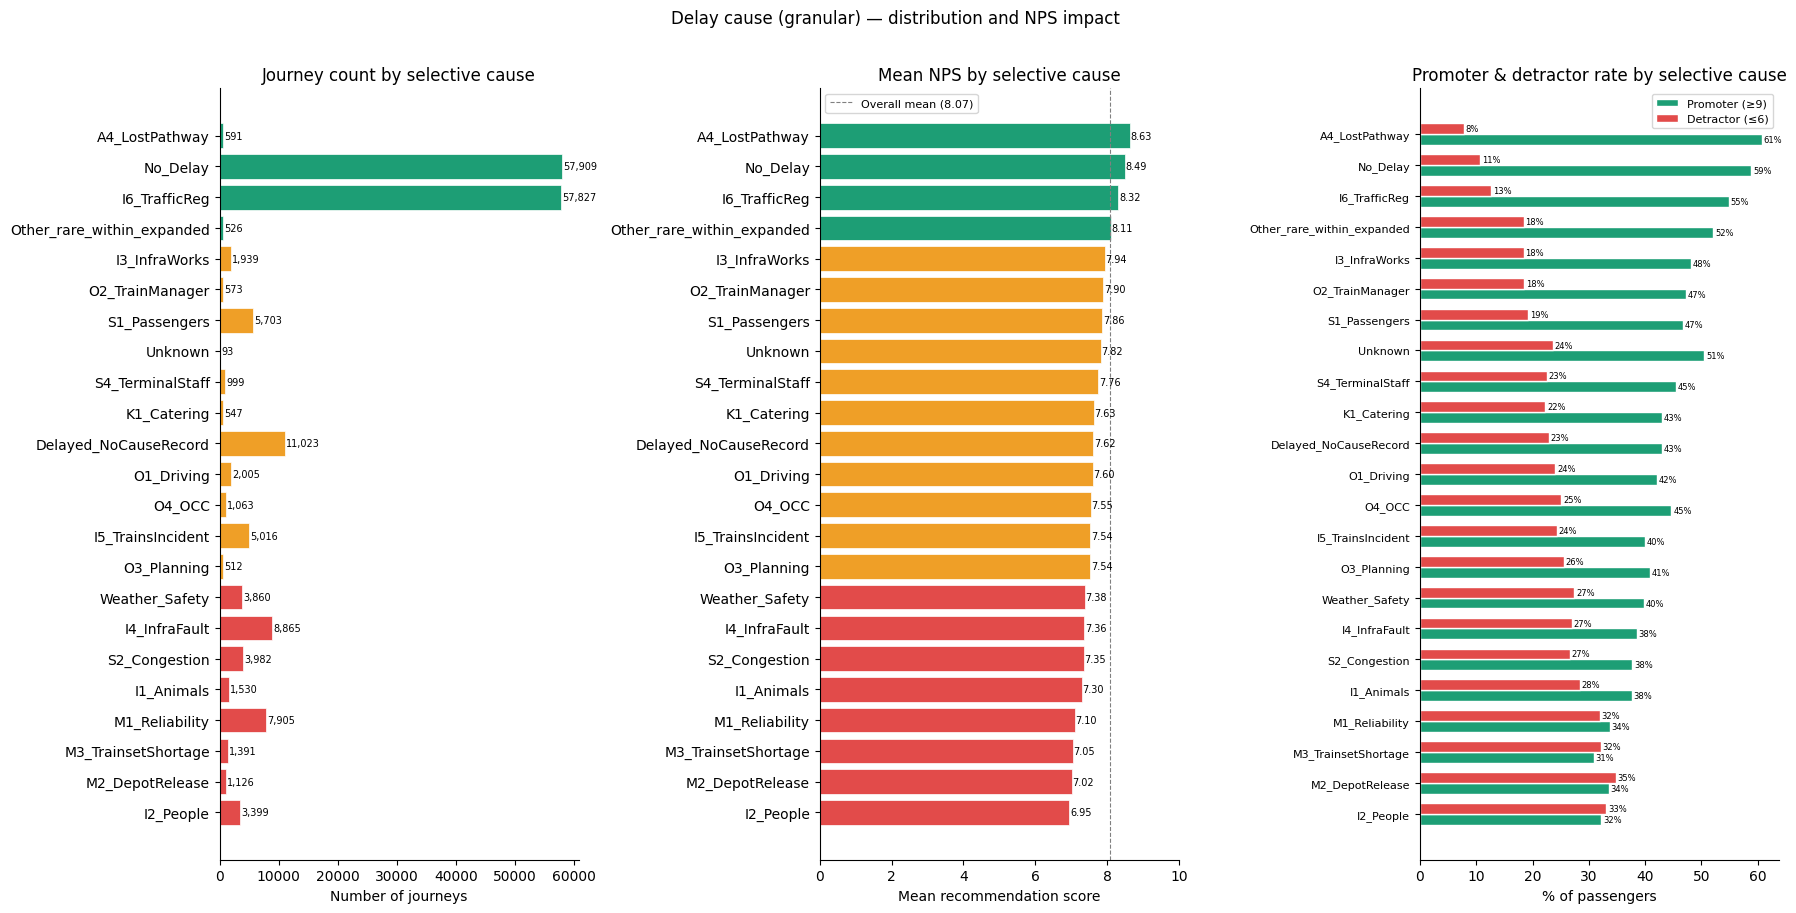

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 9))

cause_nps = df.groupby('delay_cause_select')['question_recommendation_nps_a'].agg(
    n='count',
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).round(2)

cause_order = cause_nps.sort_values('mean').index.tolist()
nps_vals = cause_nps.reindex(cause_order)['mean']

def nps_color(v):
    return '#E24B4A' if v < 7.5 else '#EF9F27' if v < 8.0 else '#1D9E75'
bar_colors = [nps_color(v) for v in nps_vals]


ax = axes[0]
counts = df['delay_cause_select'].value_counts().reindex(cause_order)
ax.barh(cause_order, counts.values, color=bar_colors, edgecolor='white', lw=0.5)
for i, v in enumerate(counts.values):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=7)
ax.set_xlabel('Number of journeys')
ax.set_title('Journey count by selective cause')
for s in ['top','right']: ax.spines[s].set_visible(False)


ax = axes[1]
ax.barh(cause_order, nps_vals, color=bar_colors, edgecolor='white', lw=0.5)
ax.axvline(df['question_recommendation_nps_a'].mean(), color='gray',
           linestyle='--', lw=0.8, label=f'Overall mean ({df["question_recommendation_nps_a"].mean():.2f})')
for i, v in enumerate(nps_vals):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=7)
ax.set_xlabel('Mean recommendation score')
ax.set_title('Mean NPS by selective cause')
ax.set_xlim(0, 10)
ax.legend(fontsize=8)
for s in ['top','right']: ax.spines[s].set_visible(False)


ax = axes[2]
pro = cause_nps.reindex(cause_order)['pct_promoter']
det = cause_nps.reindex(cause_order)['pct_detractor']
y = np.arange(len(cause_order))
width = 0.35
ax.barh(y - width/2, pro, width, label='Promoter (≥9)', color='#1D9E75', edgecolor='white')
ax.barh(y + width/2, det, width, label='Detractor (≤6)', color='#E24B4A', edgecolor='white')
for i, (p, d) in enumerate(zip(pro, det)):
    ax.text(p + 0.3, i - width/2, f'{p:.0f}%', va='center', fontsize=6)
    ax.text(d + 0.3, i + width/2, f'{d:.0f}%', va='center', fontsize=6)
ax.set_yticks(y)
ax.set_yticklabels(cause_order, fontsize=8)
ax.set_xlabel('% of passengers')
ax.set_title('Promoter & detractor rate by selective cause')
ax.legend(fontsize=8)
for s in ['top','right']: ax.spines[s].set_visible(False)

plt.suptitle('Delay cause (granular) — distribution and NPS impact', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_delay_cause_select_nps.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
check = pd.read_parquet(r"C:\Users\gehan\Downloads\thesis\extracted tables\last update data\combined_df_final.parquet")
print(check.shape)
print("duplicated cols:", check.columns.duplicated().sum())
print("cause_select_ cols on disk:", len([c for c in check.columns if c.startswith('cause_select_')]))

(178384, 269)
duplicated cols: 0
cause_select_ cols on disk: 22


## satisfaction items

In [27]:

if df.columns.duplicated().any():
    dupes = df.columns[df.columns.duplicated()].unique().tolist()
    print(f"Dropping {len(dupes)} duplicate column name(s): {dupes}")
    df = df.loc[:, ~df.columns.duplicated()]

sat_cols = [c for c in df.columns
            if str(df[c].dtype) == 'Int8'
            and c.startswith('question_')
            and 'recommendation' not in c
            and df[c].notna().mean() > 0.20]

print(f"Sat cols found: {len(sat_cols)}")
print(sat_cols)

Dropping 23 duplicate column name(s): ['cause_select_A4_LostPathway', 'cause_select_Delayed_NoCauseRecord', 'cause_select_I1_Animals', 'cause_select_I2_People', 'cause_select_I3_InfraWorks', 'cause_select_I4_InfraFault', 'cause_select_I5_TrainsIncident', 'cause_select_I6_TrafficReg', 'cause_select_K1_Catering', 'cause_select_M1_Reliability', 'cause_select_M2_DepotRelease', 'cause_select_M3_TrainsetShortage', 'cause_select_No_Delay', 'cause_select_O1_Driving', 'cause_select_O2_TrainManager', 'cause_select_O3_Planning', 'cause_select_O4_OCC', 'cause_select_Other_rare_within_expanded', 'cause_select_S1_Passengers', 'cause_select_S2_Congestion', 'cause_select_S4_TerminalStaff', 'cause_select_Unknown', 'cause_select_Weather_Safety']
Sat cols found: 27
['question_overall_satisfaction_booking_experience', 'question_overall_satisfaction_wifi_onboard_the_train', 'question_overall_satisfaction_experience_at_departure_station', 'question_overall_satisfaction_journey_punctuality', 'question_overal

In [28]:

# all Int8 question columns with >20% coverage
sat_cols = [c for c in df.columns
            if str(df[c].dtype) == 'Int8'
            and c.startswith('question_')
            and 'recommendation' not in c
            and 'overall_rating' not in c
            and df[c].notna().mean() > 0.20]

print(f"Satisfaction columns (>20% coverage): {len(sat_cols)}")
print()

sat_summary = []
for c in sat_cols:
    vals = df[c].dropna().astype(float)
    corr = float(df['question_recommendation_nps_a'].corr(df[c].astype(float), method='spearman'))
    sat_summary.append({
        'column': c.replace('question_overall_satisfaction_','sat: ')
                   .replace('question_staff_manners_','staff: ')
                   .replace('question_','')[:60],
        'coverage_pct': round(df[c].notna().mean() * 100, 1),
        'mean': round(float(vals.mean()), 3),
        'std':  round(float(vals.std()), 3),
        'rho_nps': round(corr, 3),
    })

sat_df = pd.DataFrame(sat_summary).sort_values('rho_nps', ascending=False)
print(sat_df.to_string(index=False))

Satisfaction columns (>20% coverage): 26

                                                      column  coverage_pct  mean   std  rho_nps
disruption_performan_information_on_board_the_train_e_g_from          20.2 3.503 1.204    0.520
                                        ticket_price_satisfa          95.4 3.421 1.076    0.464
                              sat: comfort_onboard_the_train          99.3 4.050 1.064    0.459
                    sat: overall_service_from_eurostar_staff          94.7 4.246 0.985    0.456
                        sat: experience_at_departure_station          99.6 3.714 1.267    0.455
          sat: information_provided_to_you_before_travelling          99.1 4.301 1.028    0.452
               at_the_station_checking_in_to_departures_area          22.0 3.850 1.148    0.446
                                    sat: journey_punctuality          99.0 3.976 1.402    0.440
                           at_the_station_boarding_the_train          24.9 4.061 0.985    0.44

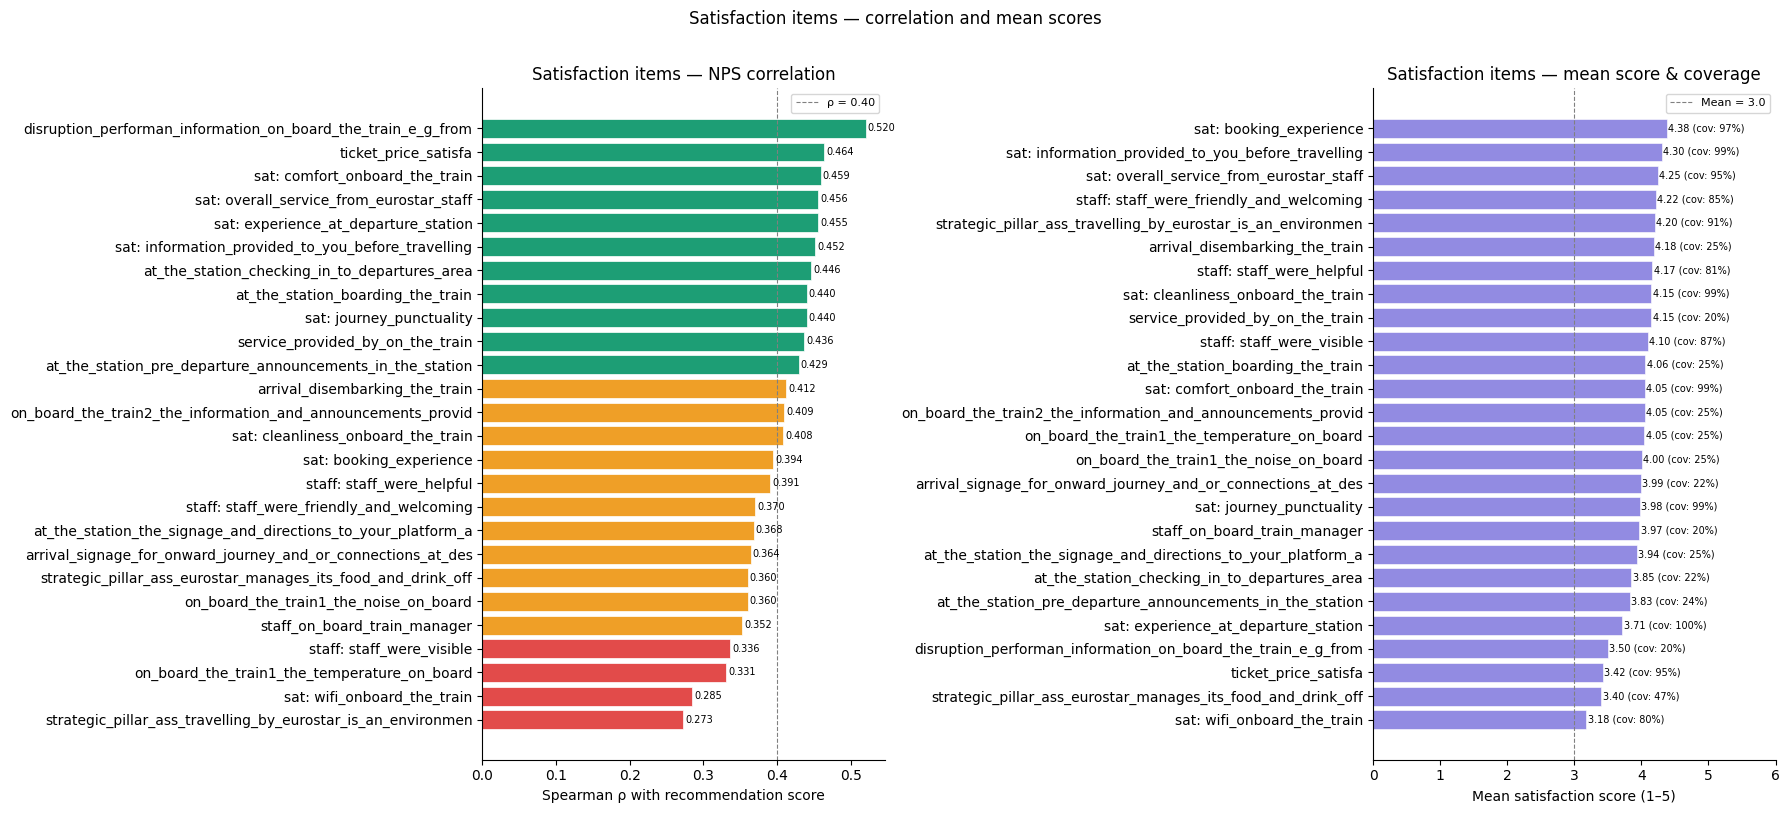

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))


ax = axes[0]
sat_plot = sat_df.sort_values('rho_nps')
colors = ['#E24B4A' if v < 0.35 else '#EF9F27' if v < 0.42 else '#1D9E75'
          for v in sat_plot['rho_nps']]
bars = ax.barh(sat_plot['column'], sat_plot['rho_nps'],
               color=colors, edgecolor='white', lw=0.5)
for bar, val in zip(bars, sat_plot['rho_nps']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7)
ax.axvline(0.4, color='gray', linestyle='--', lw=0.8, label='ρ = 0.40')
ax.set_xlabel('Spearman ρ with recommendation score')
ax.set_title('Satisfaction items — NPS correlation')
ax.legend(fontsize=8)
for s in ['top','right']: ax.spines[s].set_visible(False)


ax = axes[1]
sat_plot2 = sat_df.sort_values('mean')
bars2 = ax.barh(sat_plot2['column'], sat_plot2['mean'],
                color='#7F77DD', edgecolor='white', lw=0.5, alpha=0.85)


for bar, (_, row) in zip(bars2, sat_plot2.iterrows()):
    ax.text(row['mean'] + 0.02, bar.get_y() + bar.get_height()/2,
            f'{row["mean"]:.2f} (cov: {row["coverage_pct"]:.0f}%)',
            va='center', fontsize=7)

ax.axvline(3.0, color='gray', linestyle='--', lw=0.8, label='Mean = 3.0')
ax.set_xlabel('Mean satisfaction score (1–5)')
ax.set_title('Satisfaction items — mean score & coverage')
ax.set_xlim(0, 6)
ax.legend(fontsize=8)
for s in ['top','right']: ax.spines[s].set_visible(False)

plt.suptitle('Satisfaction items — correlation and mean scores', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_satisfaction_items.png', dpi=150, bbox_inches='tight')
plt.show()

## faults, PM, cleaning

In [30]:

cm_cols    = [c for c in df.columns if c.startswith('cm_open_')] + ['total open faults']
pm_cols    = [c for c in df.columns if c.startswith('pm_days_since_')]
pm_prior   = [c for c in df.columns if c.startswith('pm_has_prior_')]
rest_cols  = [c for c in df.columns if c.startswith('restriction_open_')] + ['total restrictions']
clean_cols = ['last_clean_score', 'hours_since_last_clean', 'clean_score_routine',
              'clean_score_deep', 'clean_days_since_deep']

print(" Corrective Maintenance (CM) — zero inflation ")
for c in cm_cols:
    vals = df[c].dropna()
    zero_pct = (vals == 0).mean()
    corr = df['question_recommendation_nps_a'].corr(df[c], method='spearman')
    print(f"  {c:<35} mean={vals.mean():.3f}  zero%={zero_pct:.1%}  rho_nps={corr:.3f}")

print("\n Restrictions — zero inflation ")
for c in rest_cols:
    vals = df[c].dropna()
    zero_pct = (vals == 0).mean()
    corr = df['question_recommendation_nps_a'].corr(df[c], method='spearman')
    print(f"  {c:<40} mean={vals.mean():.3f}  zero%={zero_pct:.1%}  rho_nps={corr:.3f}")

print("\n PM days since last exam — null rate & distribution ")
for c in pm_cols:
    vals = df[c].dropna()
    null_pct = df[c].isna().mean()
    corr = df['question_recommendation_nps_a'].corr(df[c], method='spearman')
    print(f"  {c:<30} null%={null_pct:.1%}  median={vals.median():.0f}d  p90={vals.quantile(0.9):.0f}d  rho_nps={corr:.3f}")

print("\n PM has prior — coverage ")
for c in pm_prior:
    print(f"  {c:<30} has_prior={df[c].mean():.1%}")

print("\n Cleaning scores ")
for c in clean_cols:
    vals = df[c].dropna()
    null_pct = df[c].isna().mean()
    corr = df['question_recommendation_nps_a'].corr(df[c], method='spearman')
    print(f"  {c:<30} null%={null_pct:.1%}  mean={vals.mean():.1f}  median={vals.median():.1f}  rho_nps={corr:.3f}")

print("\n Clean band distribution ")
print(df['clean_band'].value_counts(dropna=False))
print(f"\n NPS by clean band ")
print(df.groupby('clean_band', observed=True)['question_recommendation_nps_a'].agg(
    n='count', mean='mean', pct_promoter=lambda x: (x>=9).mean()*100,
    pct_detractor=lambda x: (x<=6).mean()*100
).round(2).to_string())

 Corrective Maintenance (CM) — zero inflation 
  cm_open_climate                     mean=2.405  zero%=66.3%  rho_nps=-0.106
  cm_open_wifi                        mean=0.075  zero%=96.6%  rho_nps=-0.019
  cm_open_comms                       mean=0.131  zero%=89.0%  rho_nps=-0.055
  cm_open_interior                    mean=6.253  zero%=66.3%  rho_nps=-0.105
  cm_open_catering                    mean=2.083  zero%=67.6%  rho_nps=-0.098
  cm_open_toilet                      mean=3.559  zero%=66.3%  rho_nps=-0.106
  cm_open_cleaning                    mean=1.855  zero%=68.2%  rho_nps=-0.102
  total open faults                   mean=16.360  zero%=66.3%  rho_nps=-0.105

 Restrictions — zero inflation 
  restriction_open_Toilets                 mean=0.016  zero%=98.6%  rho_nps=0.005
  restriction_open_Air Conditioning        mean=0.098  zero%=92.9%  rho_nps=0.020
  restriction_open_Refrigeration           mean=0.024  zero%=97.7%  rho_nps=0.002
  restriction_open_Windows                 mean=0

In [31]:
cm_zero = (df['cm_open_interior'] == 0)
pm_null = df['pm_days_since_interior'].isna()
clean_null = df['clean_score_routine'].isna()

print(pd.crosstab(cm_zero, pm_null))
print(pd.crosstab(cm_zero, clean_null))

if 'is_channel' in df.columns:
    for c in ['cm_open_interior', 'pm_days_since_interior', 'clean_score_routine']:
        print(c, df.groupby('is_channel')[c].apply(lambda x: x.isna().mean() if x.dtype != bool else (x==0).mean()))

pm_days_since_interior   False  True 
cm_open_interior                     
False                        0  60181
True                    118192     11
clean_score_routine   False  True 
cm_open_interior                  
False                     0  60181
True                 116220   1983
cm_open_interior is_channel
0    0.0
1    0.0
Name: cm_open_interior, dtype: float64
pm_days_since_interior is_channel
0    0.968979
1    0.000000
Name: pm_days_since_interior, dtype: float64
clean_score_routine is_channel
0    0.969784
1    0.016531
Name: clean_score_routine, dtype: float64


In [32]:
print(df.groupby('clean_band', observed=True, dropna=False)['question_recommendation_nps_a'].agg(
    n='count', mean='mean', pct_promoter=lambda x: (x>=9).mean()*100,
    pct_detractor=lambda x: (x<=6).mean()*100
).round(2).to_string())

                n  mean  pct_promoter  pct_detractor
clean_band                                          
Poor        12830  8.24         54.20          14.71
Acceptable  35223  8.22         54.18          14.70
Good        68167  8.24         54.13          14.45
NaN         62164  7.77         45.03          20.44


In [33]:
print(df.groupby('is_channel')['cm_open_interior'].apply(lambda x: (x==0).mean()))

is_channel
0    0.031198
1    1.000000
Name: cm_open_interior, dtype: float64


In [34]:
print(" hours_since_last_clean distribution ")
hsc = df['hours_since_last_clean'].dropna()
print(f"N with data     : {len(hsc):,} ({len(hsc)/len(df):.1%})")
print(f"Mean            : {hsc.mean():.1f} hours")
print(f"Median          : {hsc.median():.1f} hours")
print(f"Min             : {hsc.min():.1f} hours")
print(f"Max             : {hsc.max():.1f} hours")
print(f"p25             : {hsc.quantile(0.25):.1f} hours")
print(f"p75             : {hsc.quantile(0.75):.1f} hours")
print(f"p90             : {hsc.quantile(0.90):.1f} hours")
print(f"p99             : {hsc.quantile(0.99):.1f} hours")

print(f"\n% cleaned within 24h  : {(hsc <= 24).mean():.1%}")
print(f"% cleaned within 48h  : {(hsc <= 48).mean():.1%}")
print(f"% cleaned within 7d   : {(hsc <= 168).mean():.1%}")
print(f"% cleaned within 14d  : {(hsc <= 336).mean():.1%}")
print(f"% over 30d ago         : {(hsc > 720).mean():.1%}")

print(f"\n NPS by cleaning recency band ")
df['clean_recency'] = pd.cut(hsc, 
    bins=[0, 24, 48, 168, 336, 99999],
    labels=['<24h', '24-48h', '2-7d', '7-14d', '>14d']
)
print(df.groupby('clean_recency', observed=True)['question_recommendation_nps_a'].agg(
    n='count', mean='mean',
    pct_promoter=lambda x: (x>=9).mean()*100,
    pct_detractor=lambda x: (x<=6).mean()*100,
).round(2).to_string())

 hours_since_last_clean distribution 
N with data     : 116,220 (65.2%)
Mean            : 317.2 hours
Median          : 250.5 hours
Min             : 0.3 hours
Max             : 1717.9 hours
p25             : 135.5 hours
p75             : 432.0 hours
p90             : 652.3 hours
p99             : 1191.5 hours

% cleaned within 24h  : 2.5%
% cleaned within 48h  : 6.3%
% cleaned within 7d   : 32.3%
% cleaned within 14d  : 63.9%
% over 30d ago         : 7.5%

 NPS by cleaning recency band 
                   n  mean  pct_promoter  pct_detractor
clean_recency                                          
<24h            2906  8.32         55.47          13.18
24-48h          4424  8.25         53.87          14.35
2-7d           30232  8.24         54.05          14.32
7-14d          36689  8.25         54.60          14.50
>14d           41969  8.22         53.78          14.89


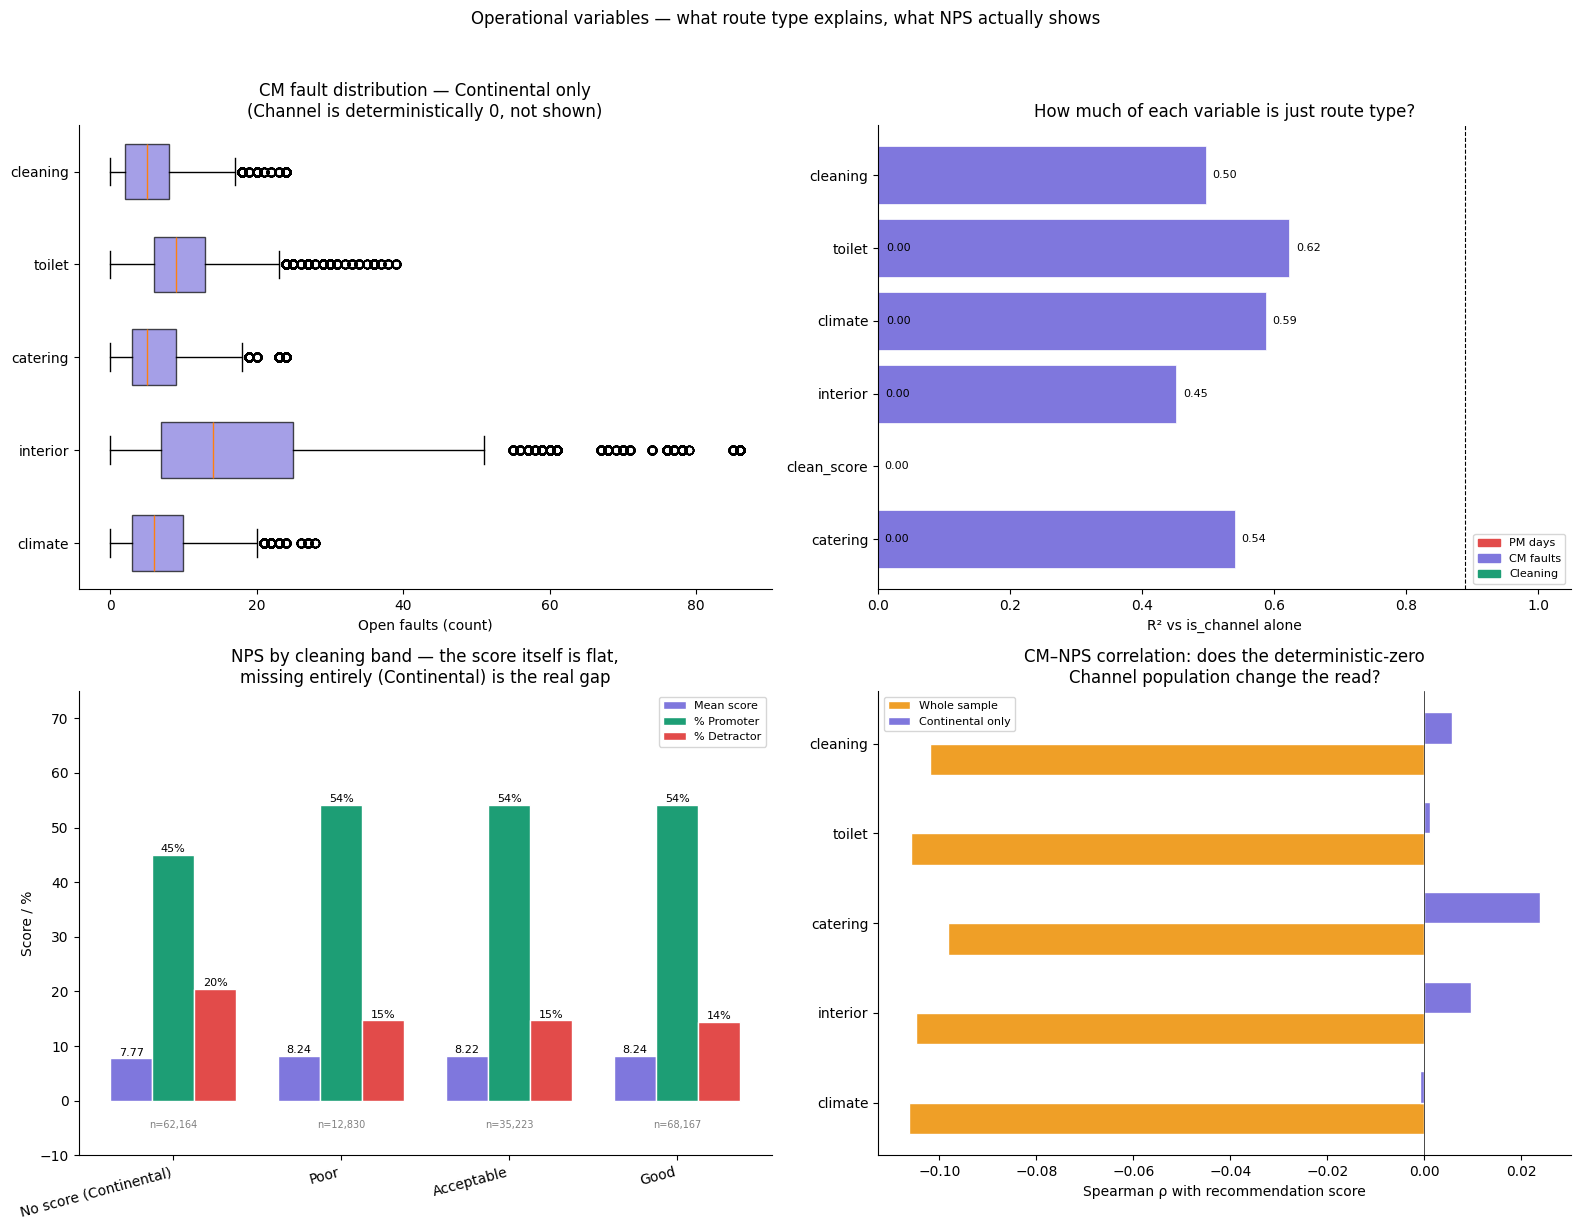

In [35]:
import numpy as np
from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
cont = df[df['is_channel'] == 0]


ax = axes[0, 0]
cm_dist_cols = ['cm_open_climate', 'cm_open_interior', 'cm_open_catering',
                'cm_open_toilet', 'cm_open_cleaning']
box_data = [cont[c].dropna() for c in cm_dist_cols]
box_labels = [c.replace('cm_open_', '') for c in cm_dist_cols]
bp = ax.boxplot(box_data, vert=False, patch_artist=True, widths=0.6)
ax.set_yticks(range(1, len(box_labels) + 1))
ax.set_yticklabels(box_labels)
for patch in bp['boxes']:
    patch.set_facecolor('#7F77DD')
    patch.set_alpha(0.7)
ax.set_xlabel('Open faults (count)')
ax.set_title('CM fault distribution — Continental only\n(Channel is deterministically 0, not shown)')
for s in ['top', 'right']: ax.spines[s].set_visible(False)


ax = axes[0, 1]
r2_vars = {
    'pm_days_since_catering': 'PM days', 'pm_days_since_climate': 'PM days',
    'pm_days_since_interior': 'PM days', 'pm_days_since_toilet': 'PM days',
    'cm_open_climate': 'CM faults', 'cm_open_interior': 'CM faults',
    'cm_open_catering': 'CM faults', 'cm_open_toilet': 'CM faults',
    'cm_open_cleaning': 'CM faults', 'clean_score_routine': 'Cleaning',
}
X = df[['is_channel']].values
rows = []
for col, fam in r2_vars.items():
    valid = df[col].notna()
    lr = LinearRegression().fit(X[valid], df.loc[valid, col].values)
    r2 = lr.score(X[valid], df.loc[valid, col].values)
    rows.append((col.replace('cm_open_', '').replace('pm_days_since_', '').replace('_routine', ''), fam, r2))

r2_df = pd.DataFrame(rows, columns=['var', 'family', 'r2']).sort_values('r2')
fam_colors = {'PM days': '#E24B4A', 'CM faults': '#7F77DD', 'Cleaning': '#1D9E75'}
bars = ax.barh(r2_df['var'], r2_df['r2'], color=[fam_colors[f] for f in r2_df['family']],
               edgecolor='white', lw=0.5)
ax.axvline(0.889, color='black', lw=0.8, ls='--')
for bar, val in zip(bars, r2_df['r2']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
ax.set_xlabel('R² vs is_channel alone')
ax.set_title('How much of each variable is just route type?')
ax.set_xlim(0, 1.05)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in fam_colors.values()]
ax.legend(handles, fam_colors.keys(), fontsize=8, loc='lower right')
for s in ['top', 'right']: ax.spines[s].set_visible(False)


ax = axes[1, 0]
clean_nps = df.groupby('clean_band', observed=True, dropna=False)['question_recommendation_nps_a'].agg(
    n='count', mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).reset_index()
clean_nps['clean_band'] = clean_nps['clean_band'].astype(object)
clean_nps.loc[clean_nps['clean_band'].isna(), 'clean_band'] = 'No score (Continental)'
order = ['No score (Continental)', 'Poor', 'Acceptable', 'Good']
clean_nps = clean_nps.set_index('clean_band').reindex(order).reset_index()

x = np.arange(len(clean_nps))
width = 0.25
ax.bar(x - width, clean_nps['mean'], width, label='Mean score', color='#7F77DD', edgecolor='white')
ax.bar(x, clean_nps['pct_promoter'], width, label='% Promoter', color='#1D9E75', edgecolor='white')
ax.bar(x + width, clean_nps['pct_detractor'], width, label='% Detractor', color='#E24B4A', edgecolor='white')
for i, row in clean_nps.iterrows():
    ax.text(i - width, row['mean'] + 0.5, f'{row["mean"]:.2f}', ha='center', fontsize=8)
    ax.text(i, row['pct_promoter'] + 0.5, f'{row["pct_promoter"]:.0f}%', ha='center', fontsize=8)
    ax.text(i + width, row['pct_detractor'] + 0.5, f'{row["pct_detractor"]:.0f}%', ha='center', fontsize=8)
    ax.text(i, -5, f'n={int(row["n"]):,}', ha='center', fontsize=7, color='gray')
ax.set_xticks(x)
ax.set_xticklabels(clean_nps['clean_band'], rotation=15, ha='right')
ax.set_ylabel('Score / %')
ax.set_title('NPS by cleaning band — the score itself is flat,\nmissing entirely (Continental) is the real gap')
ax.legend(fontsize=8)
ax.set_ylim(-10, 75)
for s in ['top', 'right']: ax.spines[s].set_visible(False)


ax = axes[1, 1]
whole_rho = [df['question_recommendation_nps_a'].corr(df[c], method='spearman') for c in cm_dist_cols]
cont_rho = [cont['question_recommendation_nps_a'].corr(cont[c], method='spearman') for c in cm_dist_cols]
x3 = np.arange(len(box_labels))
width3 = 0.35
ax.barh(x3 - width3/2, whole_rho, width3, label='Whole sample', color='#EF9F27', edgecolor='white')
ax.barh(x3 + width3/2, cont_rho, width3, label='Continental only', color='#7F77DD', edgecolor='white')
ax.set_yticks(x3)
ax.set_yticklabels(box_labels)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Spearman ρ with recommendation score')
ax.set_title('CM–NPS correlation: does the deterministic-zero\nChannel population change the read?')
ax.legend(fontsize=8)
for s in ['top', 'right']: ax.spines[s].set_visible(False)

plt.suptitle('Operational variables — what route type explains, what NPS actually shows', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_operational_variables_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## customer and service

In [36]:

print(" Price distribution ")
price = df['metadata_price']
print(f"Mean     : £{price.mean():.2f}")
print(f"Median   : £{price.median():.2f}")
print(f"p25      : £{price.quantile(0.25):.2f}")
print(f"p75      : £{price.quantile(0.75):.2f}")
print(f"p99      : £{price.quantile(0.99):.2f}")
print(f"Max      : £{price.max():.2f}")


print("\n NPS by class ")
print(df.groupby('metadata_class_of_service')['question_recommendation_nps_a'].agg(
    n='count', mean='mean',
    pct_promoter=lambda x: (x>=9).mean()*100,
    pct_detractor=lambda x: (x<=6).mean()*100,
).round(2).sort_values('mean', ascending=False).to_string())

print("\n NPS by trip purpose ")
print(df.groupby('question_main_trip_purpose')['question_recommendation_nps_a'].agg(
    n='count', mean='mean',
    pct_promoter=lambda x: (x>=9).mean()*100,
    pct_detractor=lambda x: (x<=6).mean()*100,
).round(2).sort_values('mean', ascending=False).to_string())

print("\n NPS by staff composite quartile ")
df['staff_quartile'] = pd.qcut(
    df['staff_composite'], q=4,
    labels=False, duplicates='drop'
)

print(df.groupby('staff_quartile', observed=True)['question_recommendation_nps_a'].agg(
    n='count', mean='mean',
    pct_promoter=lambda x: (x>=9).mean()*100,
    pct_detractor=lambda x: (x<=6).mean()*100,
).round(2).to_string())

print("\n Price correlation with NPS ")
print(f"Spearman rho (price vs NPS)          : {df['metadata_price'].corr(df['question_recommendation_nps_a'], method='spearman'):.3f}")
print(f"Spearman rho (class_encoded vs NPS)  : {df['class_encoded'].corr(df['question_recommendation_nps_a'], method='spearman'):.3f}")
print(f"Spearman rho (staff_composite vs NPS): {df['staff_composite'].astype(float).corr(df['question_recommendation_nps_a'], method='spearman'):.3f}")

 Price distribution 
Mean     : £94.02
Median   : £75.00
p25      : £49.00
p75      : £119.00
p99      : £325.00
Max      : £553.00

 NPS by class 
                                n  mean  pct_promoter  pct_detractor
metadata_class_of_service                                           
Wheelchair Companion          265  8.88         70.94           7.92
Wheelchair Space              334  8.61         68.56          11.68
Eurostar Standard          130557  8.09         50.96          16.26
Eurostar Plus               37328  8.07         51.37          16.68
Eurostar Premier             9900  7.81         48.54          21.21

 NPS by trip purpose 
                                    n  mean  pct_promoter  pct_detractor
question_main_trip_purpose                                              
Leisure                        106831  8.24         54.73          14.40
Visiting friends or relatives   42291  8.09         50.29          16.43
Business                        27806  7.46         38

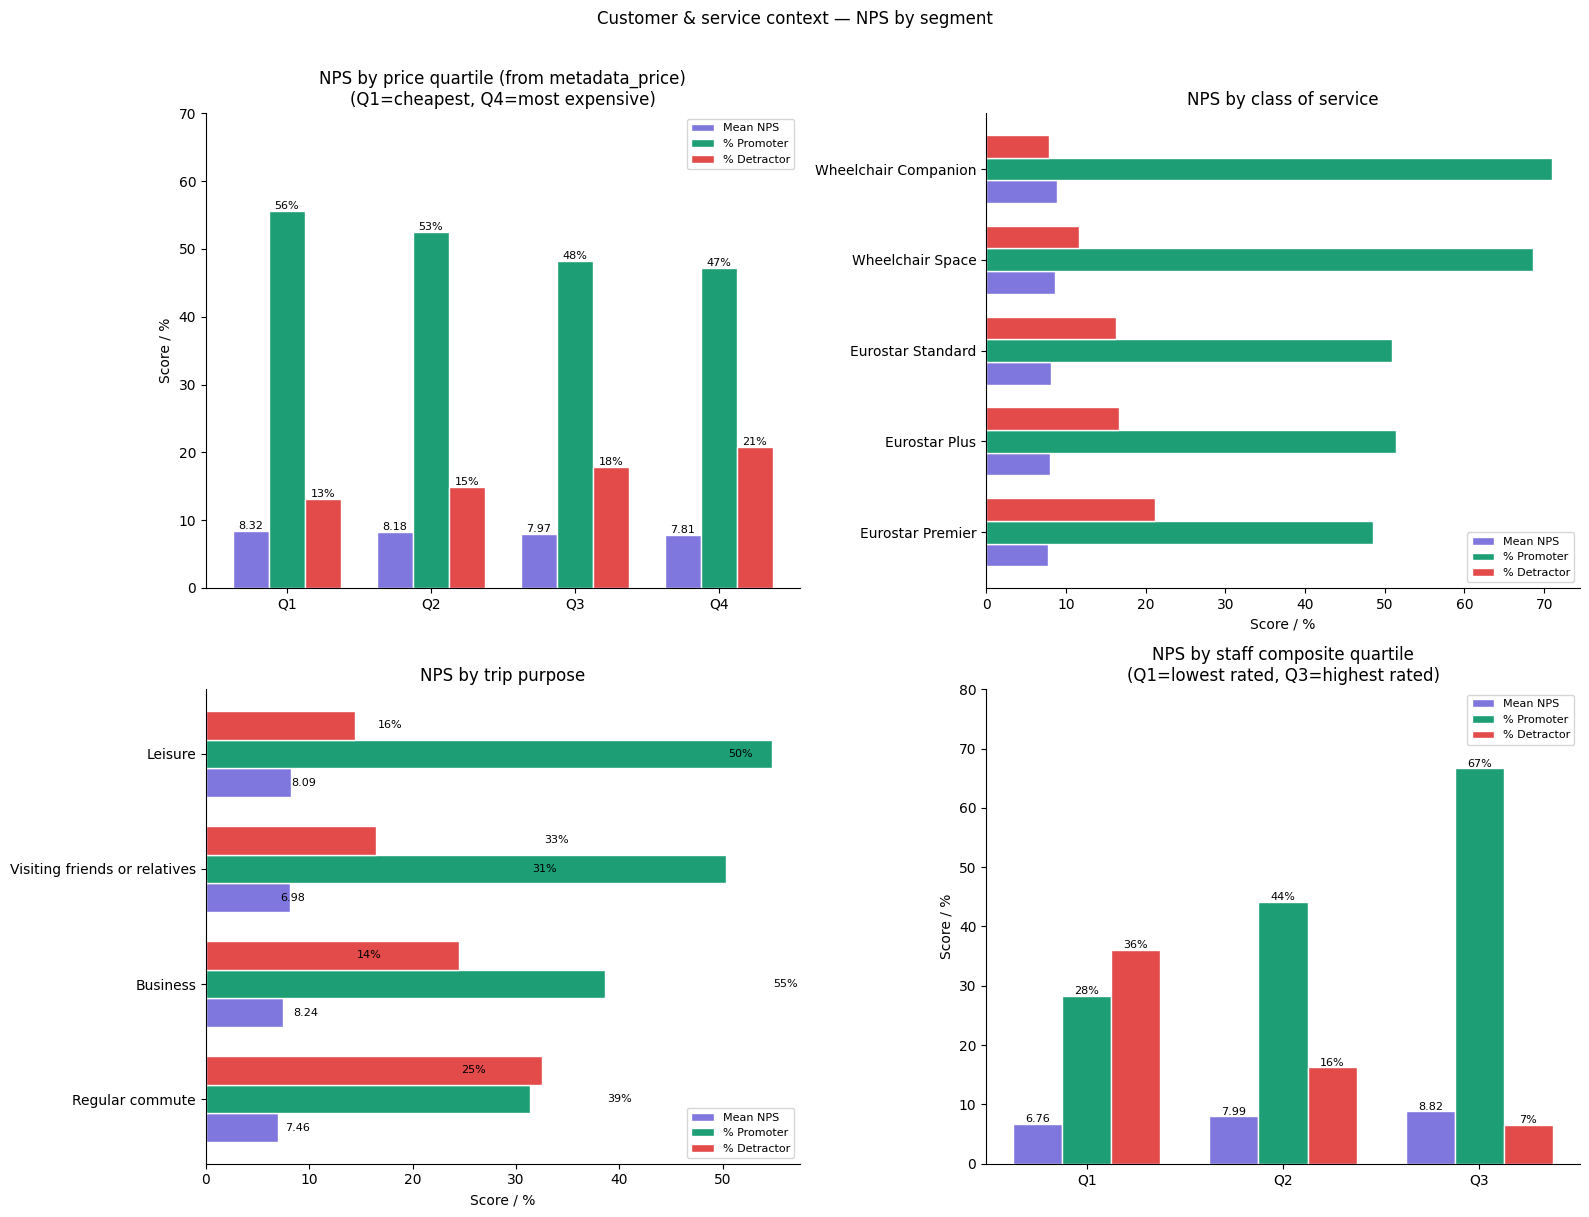

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


ax = axes[0, 0]
price_q = pd.qcut(df['metadata_price'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
pq = df.groupby(price_q, observed=True)['question_recommendation_nps_a'].agg(
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).reset_index()

x = np.arange(len(pq))
width = 0.25
ax.bar(x - width, pq['mean'],         width, label='Mean NPS',    color='#7F77DD', edgecolor='white')
ax.bar(x,         pq['pct_promoter'], width, label='% Promoter',  color='#1D9E75', edgecolor='white')
ax.bar(x + width, pq['pct_detractor'],width, label='% Detractor', color='#E24B4A', edgecolor='white')

for i, row in pq.iterrows():
    ax.text(i - width, row['mean'] + 0.3,          f'{row["mean"]:.2f}',  ha='center', fontsize=8)
    ax.text(i,         row['pct_promoter'] + 0.3,  f'{row["pct_promoter"]:.0f}%',  ha='center', fontsize=8)
    ax.text(i + width, row['pct_detractor'] + 0.3, f'{row["pct_detractor"]:.0f}%', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(pq['metadata_price'].astype(str))
ax.set_ylabel('Score / %')
ax.set_title('NPS by price quartile (from metadata_price)\n(Q1=cheapest, Q4=most expensive)')
ax.legend(fontsize=8)
ax.set_ylim(0, 70)
for s in ['top','right']: ax.spines[s].set_visible(False)


ax = axes[0, 1]
cls = df.groupby('metadata_class_of_service')['question_recommendation_nps_a'].agg(
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).reset_index().sort_values('mean', ascending=True)

x2 = np.arange(len(cls))
width2 = 0.25
ax.barh(x2 - width2, cls['mean'],         width2, label='Mean NPS',    color='#7F77DD', edgecolor='white')
ax.barh(x2,          cls['pct_promoter'], width2, label='% Promoter',  color='#1D9E75', edgecolor='white')
ax.barh(x2 + width2, cls['pct_detractor'],width2, label='% Detractor', color='#E24B4A', edgecolor='white')

ax.set_yticks(x2)
ax.set_yticklabels(cls['metadata_class_of_service'])
ax.set_xlabel('Score / %')
ax.set_title('NPS by class of service')
ax.legend(fontsize=8)
for s in ['top','right']: ax.spines[s].set_visible(False)


ax = axes[1, 0]
tp = df.groupby('question_main_trip_purpose')['question_recommendation_nps_a'].agg(
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).reset_index().sort_values('mean', ascending=True)

x3 = np.arange(len(tp))
ax.barh(x3 - width2, tp['mean'],         width2, label='Mean NPS',    color='#7F77DD', edgecolor='white')
ax.barh(x3,          tp['pct_promoter'], width2, label='% Promoter',  color='#1D9E75', edgecolor='white')
ax.barh(x3 + width2, tp['pct_detractor'],width2, label='% Detractor', color='#E24B4A', edgecolor='white')

for i, row in tp.iterrows():
    ax.text(row['mean'] + 0.2,         i - width2, f'{row["mean"]:.2f}',  va='center', fontsize=8)
    ax.text(row['pct_promoter'] + 0.2, i,          f'{row["pct_promoter"]:.0f}%',  va='center', fontsize=8)
    ax.text(row['pct_detractor'] + 0.2,i + width2, f'{row["pct_detractor"]:.0f}%', va='center', fontsize=8)

ax.set_yticks(x3)
ax.set_yticklabels(tp['question_main_trip_purpose'])
ax.set_xlabel('Score / %')
ax.set_title('NPS by trip purpose')
ax.legend(fontsize=8)
for s in ['top','right']: ax.spines[s].set_visible(False)

ax = axes[1, 1]
sq = df.groupby('staff_quartile', observed=True)['question_recommendation_nps_a'].agg(
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).reset_index()

x4 = np.arange(len(sq))
ax.bar(x4 - width, sq['mean'],         width, label='Mean NPS',    color='#7F77DD', edgecolor='white')
ax.bar(x4,         sq['pct_promoter'], width, label='% Promoter',  color='#1D9E75', edgecolor='white')
ax.bar(x4 + width, sq['pct_detractor'],width, label='% Detractor', color='#E24B4A', edgecolor='white')

for i, row in sq.iterrows():
    ax.text(i - width, row['mean'] + 0.3,          f'{row["mean"]:.2f}',  ha='center', fontsize=8)
    ax.text(i,         row['pct_promoter'] + 0.3,  f'{row["pct_promoter"]:.0f}%',  ha='center', fontsize=8)
    ax.text(i + width, row['pct_detractor'] + 0.3, f'{row["pct_detractor"]:.0f}%', ha='center', fontsize=8)

ax.set_xticks(x4)
ax.set_xticklabels([f'Q{int(q)+1}' for q in sq['staff_quartile']])
ax.set_ylabel('Score / %')
ax.set_title('NPS by staff composite quartile\n(Q1=lowest rated, Q3=highest rated)')
ax.legend(fontsize=8)
ax.set_ylim(0, 80)
for s in ['top','right']: ax.spines[s].set_visible(False)

plt.suptitle('Customer & service context — NPS by segment', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_customer_service_context.png', dpi=150, bbox_inches='tight')
plt.show()

## pnr


In [38]:

channel = df[df['is_channel'] == 1].copy()
pnr_mask = channel['total_pax'].notna()
pnr = channel[pnr_mask]

print(f"Channel rows          : {len(channel):,}")
print(f"Channel with PNR data : {len(pnr):,} ({len(pnr)/len(channel):.1%})")

print("\n PNR feature distributions ")
for c in ['total_pax', 'avg_group_size', 'group_pax_ratio']:
    vals = pnr[c].dropna()
    print(f"\n{c}:")
    print(f"  mean={vals.mean():.2f}  median={vals.median():.2f}  "
          f"p25={vals.quantile(0.25):.2f}  p75={vals.quantile(0.75):.2f}  "
          f"p90={vals.quantile(0.90):.2f}  max={vals.max():.2f}")

print("\n Equipment change ")
print(pnr['has_equipment_change'].value_counts())
print(f"Equipment change rate: {pnr['has_equipment_change'].mean():.1%}")

print("\n Passenger type mix ")
for c in ['pct_adult','pct_youth','pct_child','pct_senior']:
    vals = pnr[c].dropna()
    print(f"  {c:<15} mean={vals.mean():.3f}  median={vals.median():.3f}")

print("\n NPS correlations (PNR features, Channel only) ")
pnr_corr_cols = ['total_pax','avg_group_size','group_pax_ratio',
                 'has_equipment_change','pct_adult','pct_youth',
                 'pct_child','pct_senior']
for c in pnr_corr_cols:
    corr = pnr['question_recommendation_nps_a'].corr(pnr[c], method='spearman')
    print(f"  {c:<25} rho_nps={corr:.3f}")

print("\n NPS by equipment change")
print(pnr.groupby('has_equipment_change')['question_recommendation_nps_a'].agg(
    n='count', mean='mean',
    pct_promoter=lambda x: (x>=9).mean()*100,
    pct_detractor=lambda x: (x<=6).mean()*100,
).round(2).to_string())

print("\n NPS by total_pax quartile ")
pnr['pax_quartile'] = pd.qcut(pnr['total_pax'], q=4, labels=['Q1','Q2','Q3','Q4'])
print(pnr.groupby('pax_quartile', observed=True)['question_recommendation_nps_a'].agg(
    n='count', mean='mean',
    pct_promoter=lambda x: (x>=9).mean()*100,
    pct_detractor=lambda x: (x<=6).mean()*100,
).round(2).to_string())

Channel rows          : 116,265
Channel with PNR data : 108,687 (93.5%)

 PNR feature distributions 

total_pax:
  mean=340.14  median=344.00  p25=300.00  p75=397.00  p90=410.00  max=540.00

avg_group_size:
  mean=1.72  median=1.66  p25=1.49  p75=1.89  p90=2.13  max=4.33

group_pax_ratio:
  mean=0.64  median=0.65  p25=0.55  p75=0.73  p90=0.80  max=0.95

 Equipment change 
has_equipment_change
0.0    99724
1.0     8963
Name: count, dtype: int64
Equipment change rate: 8.2%

 Passenger type mix 
  pct_adult       mean=0.790  median=0.797
  pct_youth       mean=0.101  median=0.094
  pct_child       mean=0.044  median=0.034
  pct_senior      mean=0.065  median=0.059

 NPS correlations (PNR features, Channel only) 
  total_pax                 rho_nps=-0.068
  avg_group_size            rho_nps=-0.005
  group_pax_ratio           rho_nps=-0.002
  has_equipment_change      rho_nps=-0.066
  pct_adult                 rho_nps=0.024
  pct_youth                 rho_nps=-0.032
  pct_child             

In [39]:
df['pax_quartile_check'] = pd.qcut(df['total_pax'], q=4, labels=['Q1','Q2','Q3','Q4'])
print(df.groupby('pax_quartile_check')['total_pax'].agg(['min','max','mean']))

                      min    max        mean
pax_quartile_check                          
Q1                    6.0  300.0  264.620139
Q2                  301.0  344.0  322.978146
Q3                  345.0  397.0  370.481449
Q4                  398.0  540.0  414.410290


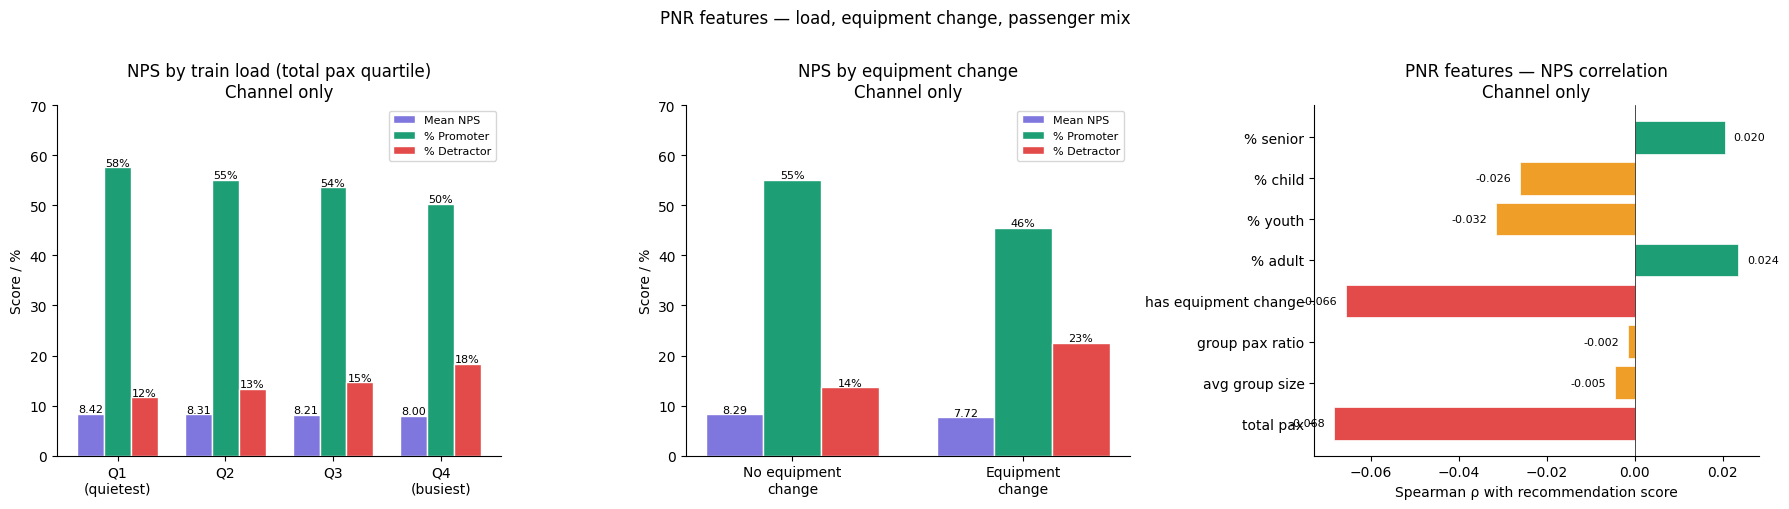

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


ax = axes[0]
pq2 = pnr.groupby('pax_quartile', observed=True)['question_recommendation_nps_a'].agg(
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).reset_index()

x = np.arange(len(pq2))
width = 0.25
ax.bar(x - width, pq2['mean'],         width, label='Mean NPS',    color='#7F77DD', edgecolor='white')
ax.bar(x,         pq2['pct_promoter'], width, label='% Promoter',  color='#1D9E75', edgecolor='white')
ax.bar(x + width, pq2['pct_detractor'],width, label='% Detractor', color='#E24B4A', edgecolor='white')
for i, row in pq2.iterrows():
    ax.text(i - width, row['mean'] + 0.3,          f'{row["mean"]:.2f}',  ha='center', fontsize=8)
    ax.text(i,         row['pct_promoter'] + 0.3,  f'{row["pct_promoter"]:.0f}%',  ha='center', fontsize=8)
    ax.text(i + width, row['pct_detractor'] + 0.3, f'{row["pct_detractor"]:.0f}%', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(['Q1\n(quietest)','Q2','Q3','Q4\n(busiest)'])
ax.set_ylabel('Score / %')
ax.set_title('NPS by train load (total pax quartile)\nChannel only')
ax.legend(fontsize=8)
ax.set_ylim(0, 70)
for s in ['top','right']: ax.spines[s].set_visible(False)


ax = axes[1]
eq = pnr.groupby('has_equipment_change')['question_recommendation_nps_a'].agg(
    mean='mean',
    pct_promoter=lambda x: (x >= 9).mean() * 100,
    pct_detractor=lambda x: (x <= 6).mean() * 100,
).reset_index()

x2 = np.arange(2)
ax.bar(x2 - width, eq['mean'],         width, label='Mean NPS',    color='#7F77DD', edgecolor='white')
ax.bar(x2,         eq['pct_promoter'], width, label='% Promoter',  color='#1D9E75', edgecolor='white')
ax.bar(x2 + width, eq['pct_detractor'],width, label='% Detractor', color='#E24B4A', edgecolor='white')
for i, row in eq.iterrows():
    ax.text(i - width, row['mean'] + 0.3,          f'{row["mean"]:.2f}',  ha='center', fontsize=8)
    ax.text(i,         row['pct_promoter'] + 0.3,  f'{row["pct_promoter"]:.0f}%',  ha='center', fontsize=8)
    ax.text(i + width, row['pct_detractor'] + 0.3, f'{row["pct_detractor"]:.0f}%', ha='center', fontsize=8)
ax.set_xticks(x2)
ax.set_xticklabels(['No equipment\nchange', 'Equipment\nchange'])
ax.set_ylabel('Score / %')
ax.set_title('NPS by equipment change\nChannel only')
ax.legend(fontsize=8)
ax.set_ylim(0, 70)
for s in ['top','right']: ax.spines[s].set_visible(False)


ax = axes[2]
pnr_corrs = {c: pnr['question_recommendation_nps_a'].corr(pnr[c], method='spearman')
             for c in pnr_corr_cols}
labels = [c.replace('pct_','% ').replace('_',' ') for c in pnr_corrs.keys()]
vals   = list(pnr_corrs.values())
colors = ['#E24B4A' if v < -0.05 else '#EF9F27' if v < 0 else '#1D9E75' for v in vals]
bars = ax.barh(labels, vals, color=colors, edgecolor='white', lw=0.5)
for bar, val in zip(bars, vals):
    xpos = val + 0.002 if val >= 0 else val - 0.002
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Spearman ρ with recommendation score')
ax.set_title('PNR features — NPS correlation\nChannel only')
for s in ['top','right']: ax.spines[s].set_visible(False)

plt.suptitle('PNR features — load, equipment change, passenger mix', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_pnr_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:


model_vars = [
    # Delay
    'arrival_delay_minute', 'arrival_delay_clipped',
    'delay_gt5', 'delay_gt15', 'delay_gt30', 'delay_gt60',
    'early_journey_delay_minute',
    # Delay cause
    'cause_select_A4_LostPathway', 'cause_select_Delayed_NoCauseRecord', 'cause_select_I1_Animals', 
    'cause_select_I2_People', 'cause_select_I3_InfraWorks', 'cause_select_I4_InfraFault', 'cause_select_I5_TrainsIncident', 
    'cause_select_I6_TrafficReg', 'cause_select_K1_Catering', 'cause_select_M1_Reliability', 'cause_select_M2_DepotRelease', 
    'cause_select_M3_TrainsetShortage', 'cause_select_No_Delay', 'cause_select_O1_Driving', 'cause_select_O2_TrainManager', 
    'cause_select_O3_Planning', 'cause_select_O4_OCC', 'cause_select_Other_rare_within_expanded', 'cause_select_S1_Passengers', 
    'cause_select_S2_Congestion', 'cause_select_S4_TerminalStaff', 'cause_select_Unknown', 'cause_select_Weather_Safety'
    # Faults
    'total open faults', 'cm_open_climate', 'cm_open_toilet',
    'cm_open_interior', 'cm_open_catering', 'cm_open_cleaning',
    # Restrictions
    'total restrictions',
    # PM
    'pm_has_prior_catering', 'pm_has_prior_toilet',
    'pm_has_prior_climate', 'pm_has_prior_interior',
    # Cleaning
    'last_clean_score', 'hours_since_last_clean', 'clean_below_90',
    # Price & class
    'metadata_price', 'class_encoded',
    # Staff
    'staff_composite',
    # Temporal
    'departure_month', 'departure_weekday', 'is_weekend',
    'departure_hour_int', 'is_peak_hour',
    # Customer
    'age_encoded', 'is_business', 'is_leisure', 'is_commuter',
    'trips_l12m', 'is_frequent_traveller', 'has_connection',
    # Disruption & compensation
    'had_disruption', 'received_compensation',
    # PNR
    'total_pax', 'has_equipment_change', 'group_pax_ratio',
    # Route
    'is_channel',
    # n_trainsets
    'n_trainsets',
]

# Computing Spearman correlations
corr_results = []
for c in model_vars:
    if c not in df.columns:
        continue
    try:
        rho = df['question_recommendation_nps_a'].corr(
            df[c].astype(float), method='spearman'
        )
        corr_results.append({'variable': c, 'rho_nps': round(rho, 3)})
    except Exception:
        pass

corr_df = pd.DataFrame(corr_results).sort_values('rho_nps', ascending=False)
print(f"Variables computed: {len(corr_df)}")
print(corr_df.to_string(index=False))

Variables computed: 63
                               variable  rho_nps
                        staff_composite    0.397
                  cause_select_No_Delay    0.130
                             is_channel    0.113
                   pm_has_prior_climate    0.109
                  pm_has_prior_catering    0.109
                  pm_has_prior_interior    0.109
                            n_trainsets    0.109
                    pm_has_prior_toilet    0.105
                             is_leisure    0.103
                            age_encoded    0.100
             cause_select_I6_TrafficReg    0.069
                             is_weekend    0.025
                     total restrictions    0.020
                      departure_weekday    0.017
            cause_select_A4_LostPathway    0.013
cause_select_Other_rare_within_expanded    0.003
                         clean_below_90    0.000
                       last_clean_score   -0.000
                   cause_select_Unknown   -0.0

In [42]:

sat_cols_model = [c for c in df.columns
                  if str(df[c].dtype) == 'Int8'
                  and c.startswith('question_')
                  and 'recommendation' not in c
                  and 'overall_rating' not in c
                  and df[c].notna().mean() > 0.20]

all_model_vars = model_vars + sat_cols_model

# Deduplicate
all_model_vars = list(dict.fromkeys([c for c in all_model_vars if c in df.columns]))

print(f"Total model variables: {len(all_model_vars)}")
print("\nFull list:")
for i, c in enumerate(all_model_vars):
    print(f"  {i+1:2}. {c}")

Total model variables: 89

Full list:
   1. arrival_delay_minute
   2. arrival_delay_clipped
   3. delay_gt5
   4. delay_gt15
   5. delay_gt30
   6. delay_gt60
   7. early_journey_delay_minute
   8. cause_select_A4_LostPathway
   9. cause_select_Delayed_NoCauseRecord
  10. cause_select_I1_Animals
  11. cause_select_I2_People
  12. cause_select_I3_InfraWorks
  13. cause_select_I4_InfraFault
  14. cause_select_I5_TrainsIncident
  15. cause_select_I6_TrafficReg
  16. cause_select_K1_Catering
  17. cause_select_M1_Reliability
  18. cause_select_M2_DepotRelease
  19. cause_select_M3_TrainsetShortage
  20. cause_select_No_Delay
  21. cause_select_O1_Driving
  22. cause_select_O2_TrainManager
  23. cause_select_O3_Planning
  24. cause_select_O4_OCC
  25. cause_select_Other_rare_within_expanded
  26. cause_select_S1_Passengers
  27. cause_select_S2_Congestion
  28. cause_select_S4_TerminalStaff
  29. cause_select_Unknown
  30. cm_open_climate
  31. cm_open_toilet
  32. cm_open_interior
  33. c

In [43]:
import warnings
warnings.filterwarnings('ignore')


corr_data = pd.DataFrame()
for c in all_model_vars:
    try:
        corr_data[c] = pd.to_numeric(df[c], errors='coerce')
    except Exception:
        pass

print(f"Columns in correlation matrix: {corr_data.shape[1]}")


nps = pd.to_numeric(df['question_recommendation_nps_a'], errors='coerce')

full_corr_nps = []
for c in corr_data.columns:
    rho = nps.corr(corr_data[c], method='spearman')
    full_corr_nps.append({'variable': c, 'rho_nps': round(rho, 3)})

full_corr_df = pd.DataFrame(full_corr_nps).sort_values('rho_nps', ascending=False)
print("\n All variables ranked by NPS correlation ")
print(full_corr_df.to_string(index=False))


print("\nComputing inter-feature correlation matrix...")
feat_corr = corr_data.corr(method='spearman')
print(f"Matrix shape: {feat_corr.shape}")


high_corr = []
for i in range(len(feat_corr.columns)):
    for j in range(i+1, len(feat_corr.columns)):
        val = feat_corr.iloc[i, j]
        if abs(val) > 0.7:
            high_corr.append({
                'var1': feat_corr.columns[i],
                'var2': feat_corr.columns[j],
                'rho': round(val, 3)
            })

high_corr_df = pd.DataFrame(high_corr).sort_values('rho', key=abs, ascending=False)
print(f"\n High inter-feature correlations (|rho| > 0.7): {len(high_corr_df)} pairs ")
print(high_corr_df.to_string(index=False))

Columns in correlation matrix: 89

 All variables ranked by NPS correlation 
                                                                                                                                       variable  rho_nps
                                                      question_disruption_performan_information_on_board_the_train_e_g_from_staff_announcements    0.520
                                                                                                                  question_ticket_price_satisfa    0.464
                                                                                        question_overall_satisfaction_comfort_onboard_the_train    0.459
                                                                              question_overall_satisfaction_overall_service_from_eurostar_staff    0.456
                                                                                  question_overall_satisfaction_experience_at_departure_station    0.455
     

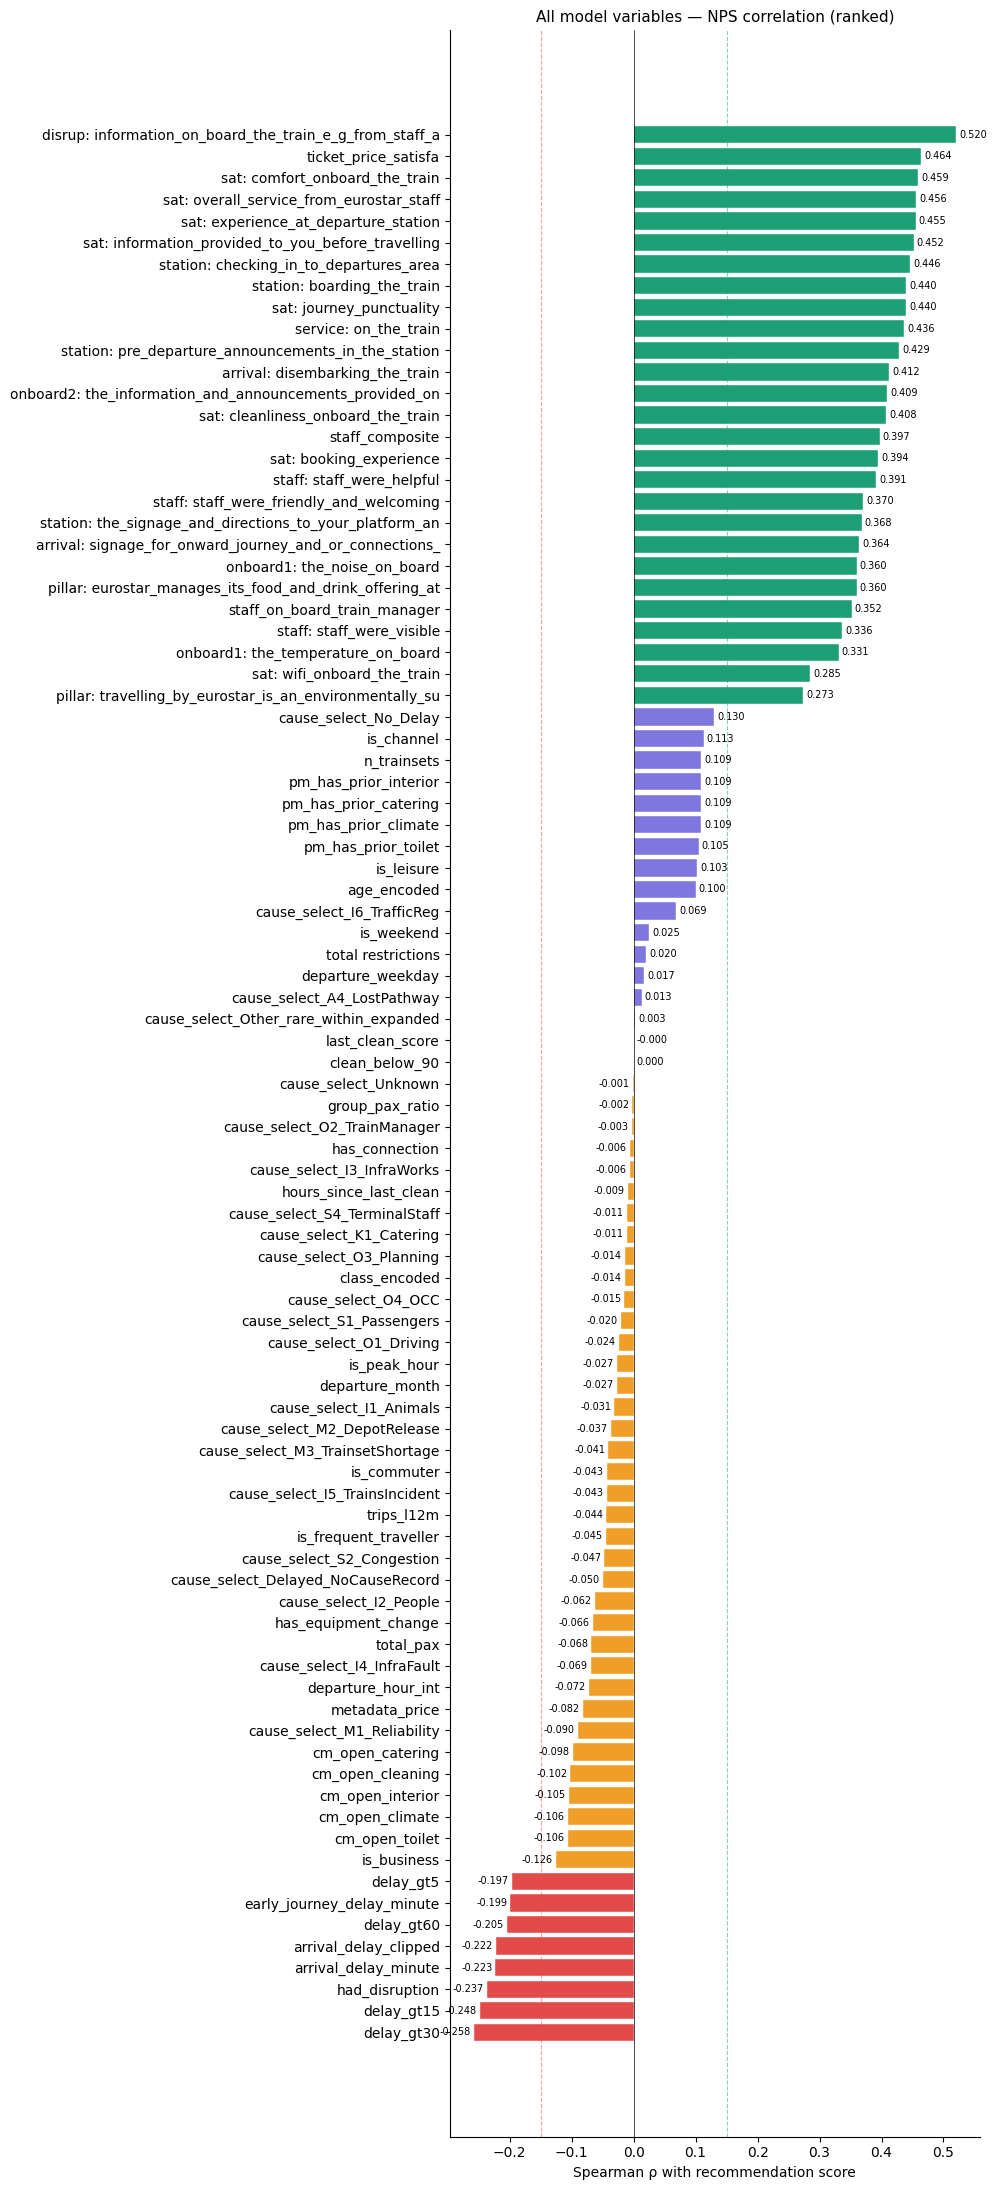

In [44]:

fig, ax = plt.subplots(figsize=(10, 22))

plot_df = full_corr_df.sort_values('rho_nps')
short_names = [c.replace('question_overall_satisfaction_','sat: ')
                .replace('question_staff_manners_','staff: ')
                .replace('question_at_the_station_','station: ')
                .replace('question_on_board_the_train1_','onboard1: ')
                .replace('question_on_board_the_train2_','onboard2: ')
                .replace('question_disruption_performan_','disrup: ')
                .replace('question_arrival_','arrival: ')
                .replace('question_service_provided_by_','service: ')
                .replace('question_strategic_pillar_ass_','pillar: ')
                .replace('question_','')[:55]
               for c in plot_df['variable']]

colors = ['#E24B4A' if v < -0.15 else '#EF9F27' if v < 0 else
          '#1D9E75' if v > 0.15 else '#7F77DD'
          for v in plot_df['rho_nps']]

bars = ax.barh(short_names, plot_df['rho_nps'],
               color=colors, edgecolor='white', lw=0.3)
ax.axvline(0, color='black', lw=0.5)
ax.axvline(0.15,  color='#1D9E75', lw=0.8, linestyle='--', alpha=0.5)
ax.axvline(-0.15, color='#E24B4A', lw=0.8, linestyle='--', alpha=0.5)

for bar, val in zip(bars, plot_df['rho_nps']):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=7)

ax.set_xlabel('Spearman ρ with recommendation score')
ax.set_title('All model variables — NPS correlation (ranked)', fontsize=11)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09a_nps_correlations_ranked.png', dpi=150, bbox_inches='tight')
plt.show()

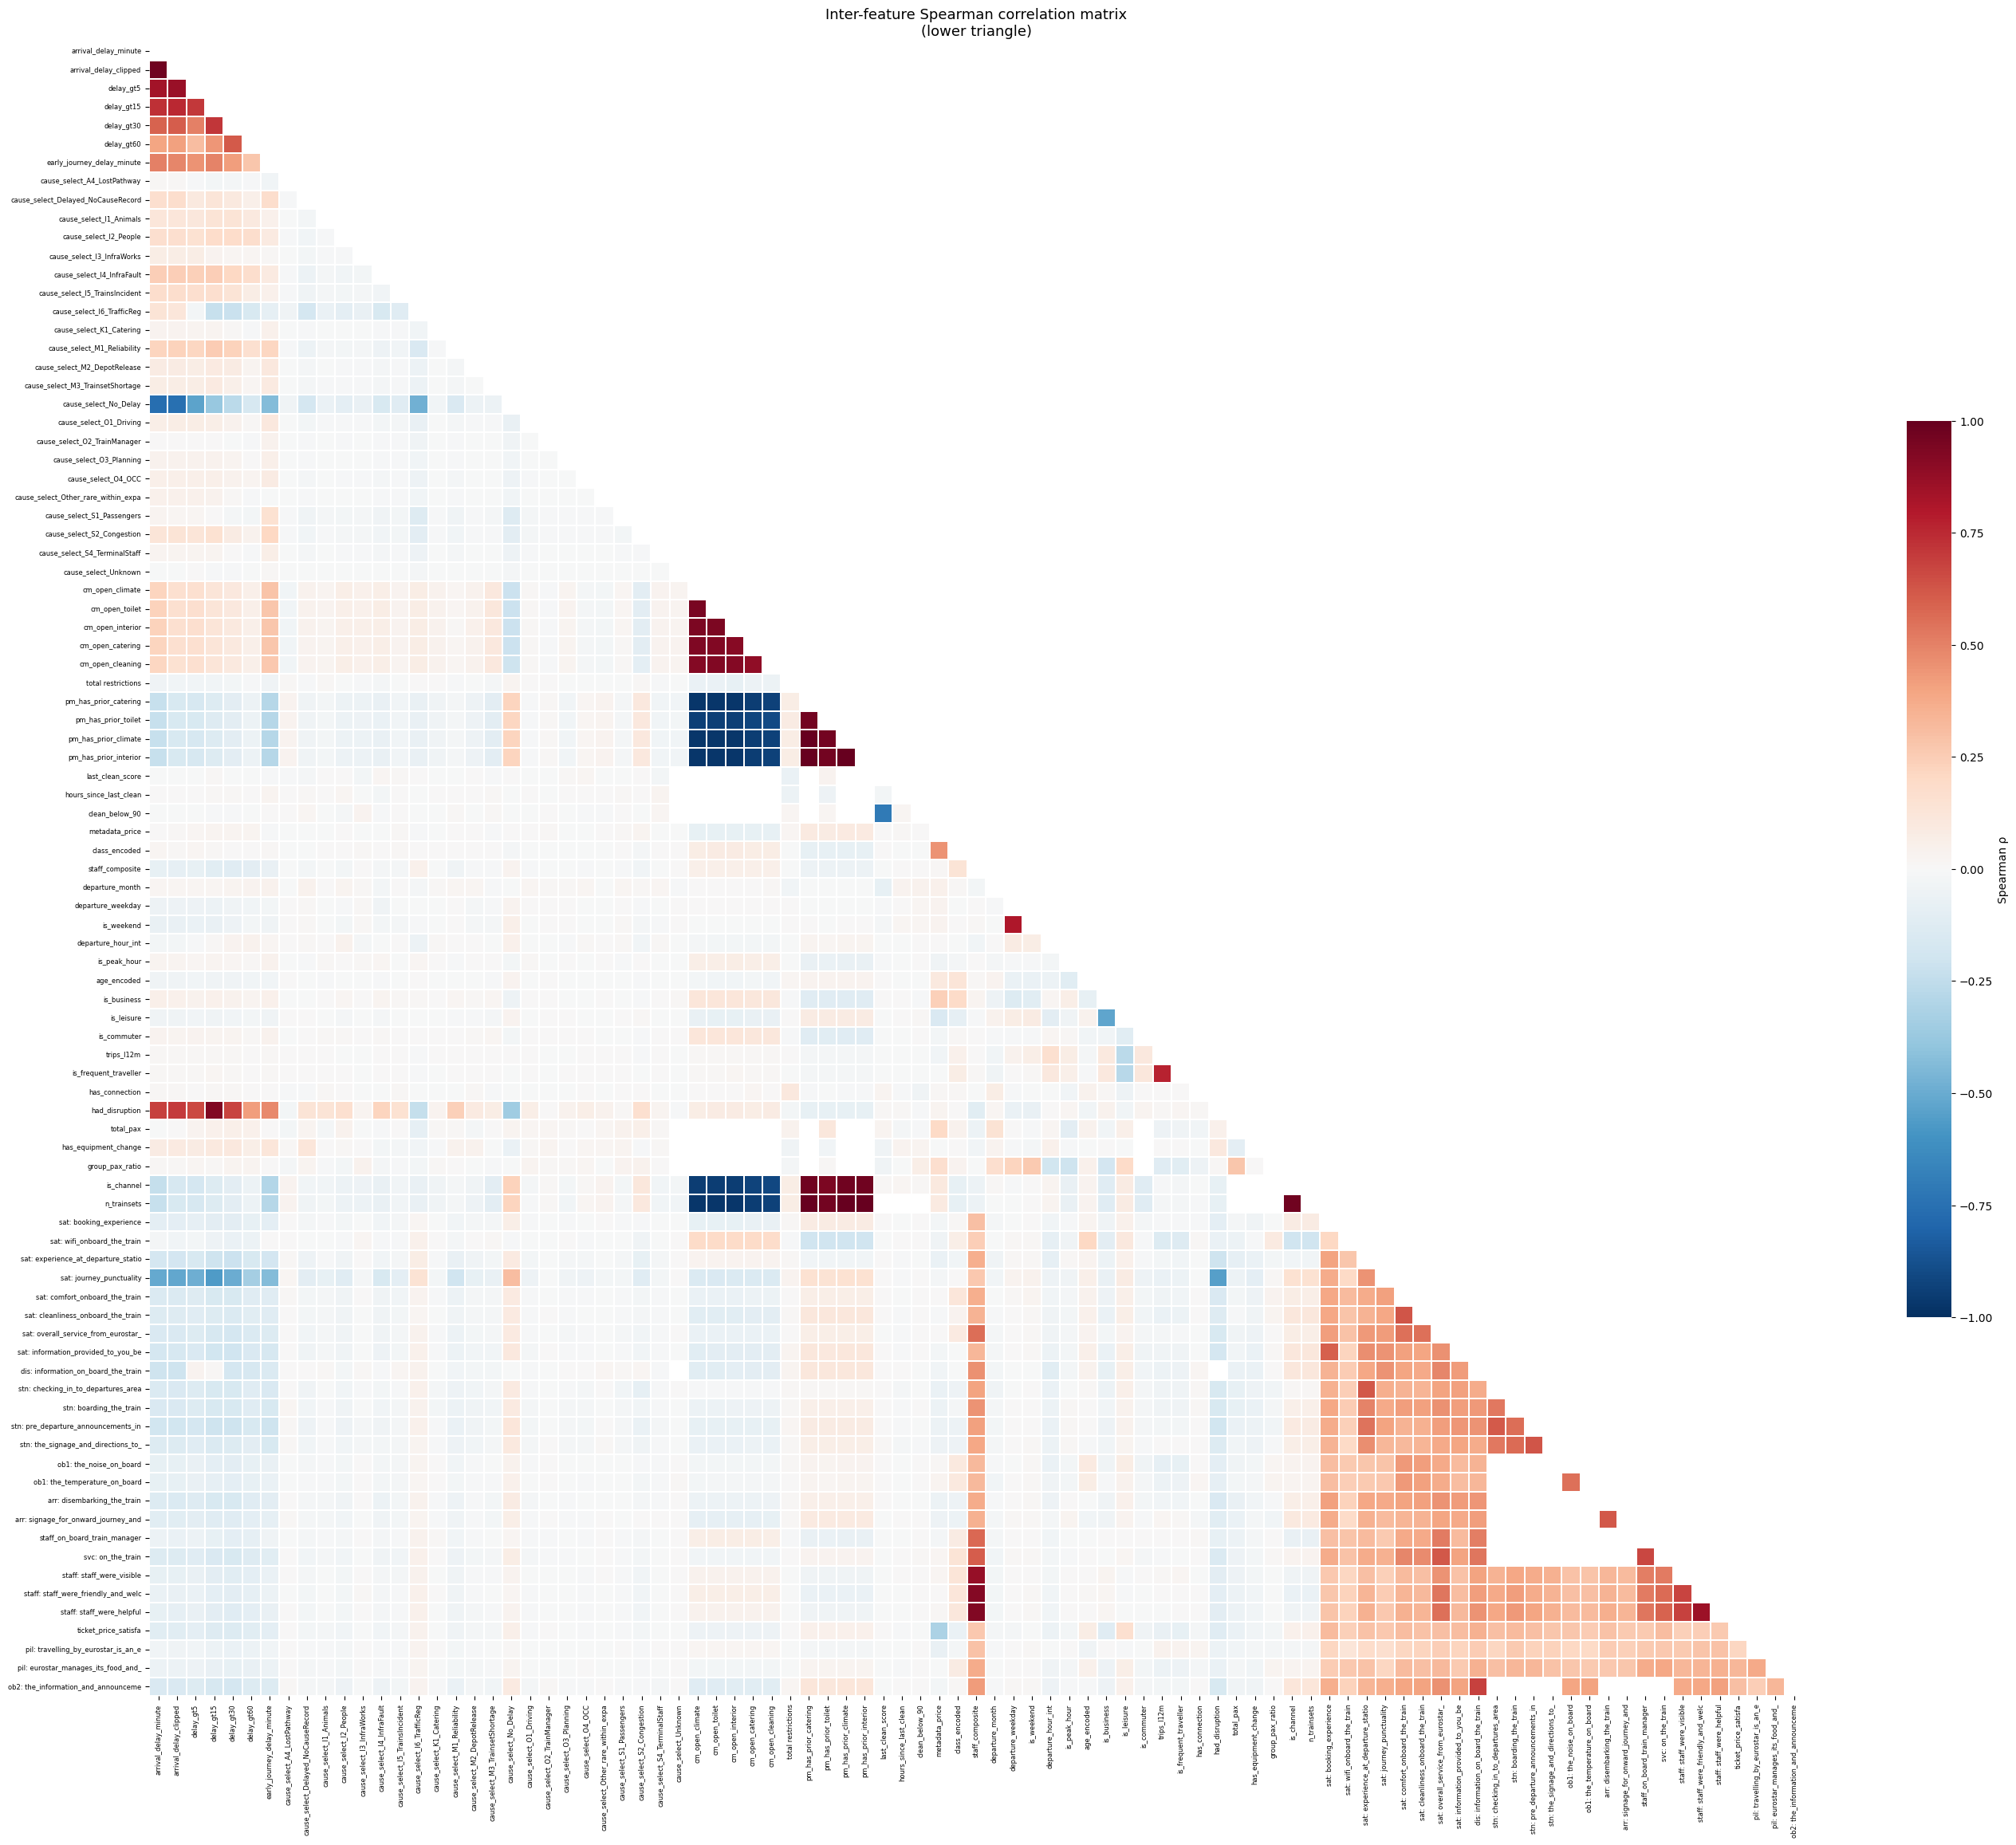

Saved.


In [45]:

short_map = {}
for c in all_model_vars:
    short = (c.replace('question_overall_satisfaction_','sat: ')
              .replace('question_staff_manners_','staff: ')
              .replace('question_at_the_station_','stn: ')
              .replace('question_on_board_the_train1_','ob1: ')
              .replace('question_on_board_the_train2_','ob2: ')
              .replace('question_disruption_performan_','dis: ')
              .replace('question_arrival_','arr: ')
              .replace('question_service_provided_by_','svc: ')
              .replace('question_strategic_pillar_ass_','pil: ')
              .replace('question_','')[:35])
    short_map[c] = short

feat_corr_plot = feat_corr.copy()
feat_corr_plot.index   = [short_map.get(c, c) for c in feat_corr_plot.index]
feat_corr_plot.columns = [short_map.get(c, c) for c in feat_corr_plot.columns]

fig, ax = plt.subplots(figsize=(28, 24))
mask = np.zeros_like(feat_corr_plot.values, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle masked

sns.heatmap(
    feat_corr_plot,
    mask=mask,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.2,
    linecolor='white',
    annot=False,
    cbar_kws={'shrink': 0.5, 'label': 'Spearman ρ'}
)

ax.set_title('Inter-feature Spearman correlation matrix\n(lower triangle)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.tick_params(axis='y', rotation=0,  labelsize=6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09b_interfeature_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved.")

## compensation

In [46]:
# does compensation amount vary meaningfully within delay_gt60 passengers?
comp_check = df[df['delay_gt60'] == 1]['compensation_liability_evouchers']
print("Among delay_gt60=1 (evouchers):")
print(comp_check.describe())
print("\nvalue counts (top 10):")
print(comp_check.value_counts().head(10))
                                                                                                                    

comp_check = df[df['delay_gt60'] == 1]['compensation_liability_cash']
print("Among delay_gt60=1 (cash):")
print(comp_check.describe())
print("\nvalue counts (top 10):")
print(comp_check.value_counts().head(10))

# and does NPS differ by compensation amount within that group?
delayed = df[df['delay_gt60'] == 1].copy()
print("\nNPS by compensation amount (delay_gt60 only):")
print(delayed.groupby('compensation_liability_evouchers')['question_recommendation_nps_a'].agg(['mean','count']).round(2))

# and does NPS differ by compensation amount within that group?
delayed = df[df['delay_gt60'] == 1].copy()
print("\nNPS by compensation amount (delay_gt60 only):")
print(delayed.groupby('compensation_liability_cash')['question_recommendation_nps_a'].agg(['mean','count']).round(2))

Among delay_gt60=1 (evouchers):
count     9769
unique       4
top       0.30
freq      4897
Name: compensation_liability_evouchers, dtype: object

value counts (top 10):
compensation_liability_evouchers
0.30    4897
0.75    2464
0.60    2077
0.00     331
Name: count, dtype: int64
Among delay_gt60=1 (cash):
count     9769
unique       3
top       0.25
freq      4897
Name: compensation_liability_cash, dtype: object

value counts (top 10):
compensation_liability_cash
0.25    4897
0.50    4541
0.00     331
Name: count, dtype: int64

NPS by compensation amount (delay_gt60 only):
                                  mean  count
compensation_liability_evouchers             
0.00                              6.17    331
0.30                              6.31   4897
0.60                              5.79   2077
0.75                              5.04   2464

NPS by compensation amount (delay_gt60 only):
                             mean  count
compensation_liability_cash             
0.00          

In [47]:
from scipy import stats
g0 = delayed[delayed['compensation_liability_cash']==0.00]['question_recommendation_nps_a']
g1 = delayed[delayed['compensation_liability_cash']==0.55]['question_recommendation_nps_a']
print(f"n0={len(g0)}, n1={len(g1)}")
t, p = stats.ttest_ind(g0, g1, equal_var=False)
print(f"t={t:.3f}, p={p:.4f}")


g0 = delayed[delayed['compensation_liability_evouchers']==0.00]['question_recommendation_nps_a']
g1 = delayed[delayed['compensation_liability_evouchers']==0.55]['question_recommendation_nps_a']
print(f"n0={len(g0)}, n1={len(g1)}")
t, p = stats.ttest_ind(g0, g1, equal_var=False)
print(f"t={t:.3f}, p={p:.4f}")

n0=331, n1=0
t=nan, p=nan
n0=331, n1=0
t=nan, p=nan


# cleaning up for the model


In [48]:
[c for c in df.columns if 'comp' in c.lower()]

['metadata_compensation_flag',
 'question_disruption_performan_the_compensation_you_received_as_a_result_of_this_disruption',
 'compensation_liability_evouchers',
 'compensation_liability_cash',
 'staff_composite']

In [49]:
df['question_disruption_performan_the_compensation_you_received_as_a_result_of_this_disruption'].isna().mean()

np.float64(0.9776044936765629)

In [50]:
print(df['n_trainsets'].value_counts())
print(df.groupby('n_trainsets')['is_channel'].mean().round(3))

n_trainsets
2    118192
1     60192
Name: count, dtype: int64
n_trainsets
1    0.000
2    0.984
Name: is_channel, dtype: float64


In [51]:
print(df.groupby(['n_trainsets', 'route_type', 
                  'metadata_origin_station', 
                  'metadata_destination_station']).size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
      .head(20))

     n_trainsets   route_type  metadata_origin_station  \
99             2      Channel  London St Pancras Int'l   
101            2      Channel       Paris Gare du Nord   
93             2      Channel     Brussels Midi / Zuid   
97             2      Channel  London St Pancras Int'l   
25             1  Continental     Brussels Midi / Zuid   
64             1  Continental       Paris Gare du Nord   
62             1  Continental       Paris Gare du Nord   
7              1  Continental       Amsterdam Centraal   
96             2      Channel  London St Pancras Int'l   
98             2      Channel  London St Pancras Int'l   
92             2      Channel       Amsterdam Centraal   
95             2      Channel             Lille Europe   
33             1  Continental              Cologne Hbf   
83             1  Continental       Rotterdam Centraal   
65             1  Continental       Paris Gare du Nord   
72             1  Continental       Paris Gare du Nord   
102           

## residualising

In [52]:
from sklearn.linear_model import LinearRegression
import numpy as np


model_df = df.copy()

model_df = model_df.rename(columns={
    'total open faults': 'total_open_faults',
    'total restrictions': 'total_restrictions',
})


cm_cols = [
    'cm_open_climate', 'cm_open_toilet', 'cm_open_interior',
    'cm_open_catering', 'cm_open_cleaning',
]

X_route = model_df[['is_channel']].values

for col in cm_cols:
    valid = model_df[col].notna()
    resid = np.full(len(model_df), np.nan)
    lr = LinearRegression()
    lr.fit(X_route[valid], model_df.loc[valid, col])
    resid[valid] = model_df.loc[valid, col] - lr.predict(X_route[valid])
    model_df[f'{col}_resid'] = resid
    print(f"{col}: R²={lr.score(X_route[valid], model_df.loc[valid, col]):.3f}, "
          f"resid std={np.nanstd(resid):.3f}")

drop_model = [
    # Route-type proxy
    'n_trainsets',
    'received_compensation',
    # Disruption compensation survey item — 97.8% missing
    'question_disruption_performan_the_compensation_you_received_as_a_result_of_this_disruption',
]

drop_model = [c for c in drop_model if c in model_df.columns]
model_df.drop(columns=drop_model, inplace=True)


print(f"\nOriginal df shape  : {df.shape}")
print(f"model_df shape     : {model_df.shape}")
print(f"Columns dropped    : {len(drop_model)}")

space_cols = [c for c in model_df.columns if ' ' in c]
print(f"\nRemaining space-name columns: {space_cols}")

resid_cols = [c for c in model_df.columns if '_resid' in c]
print(f"\nResidual columns added: {resid_cols}")


print(f"\nDtype summary:")
print(model_df.dtypes.value_counts())

cm_open_climate: R²=0.588, resid std=2.755
cm_open_toilet: R²=0.623, resid std=3.785
cm_open_interior: R²=0.452, resid std=9.414
cm_open_catering: R²=0.540, resid std=2.629
cm_open_cleaning: R²=0.496, resid std=2.557

Original df shape  : (178384, 274)
model_df shape     : (178384, 277)
Columns dropped    : 2

Remaining space-name columns: ['restriction_open_Air Conditioning', 'restriction_days_Air Conditioning', 'longest restriction', 'average days since last exams']

Residual columns added: ['question_residence', 'cm_open_climate_resid', 'cm_open_toilet_resid', 'cm_open_interior_resid', 'cm_open_catering_resid', 'cm_open_cleaning_resid']

Dtype summary:
int64                  88
Int8                   65
float64                62
object                 49
datetime64[us, UTC]     2
int32                   2
category                1
str                     1
Float64                 1
category                1
datetime64[us]          1
category                1
category                

In [53]:
model_df = model_df.rename(columns={
    'restriction_open_Air Conditioning': 'restriction_open_air_conditioning',
    'restriction_days_Air Conditioning': 'restriction_days_air_conditioning',
    'longest restriction': 'longest_restriction',
    'average days since last exams': 'average_days_since_last_exams',
})


space_cols = [c for c in model_df.columns if ' ' in c]
print(f"Remaining space-name columns: {space_cols}")

Remaining space-name columns: []


In [54]:
print(model_df['question_residence'].dtype)
print(model_df['question_residence'].value_counts().head())

object
question_residence
United Kingdom                     51802
France                             43608
Belgium                            24760
The Netherlands                    20580
Another country (please select)    15233
Name: count, dtype: int64


In [55]:
print('question_residence_resid' in model_df.columns)

False


In [56]:
print(f"Total columns: {len(model_df.columns)}")
print()
for i, c in enumerate(model_df.columns):
    print(f"  {i+1:3}. {c:60} {str(model_df[c].dtype)}")

Total columns: 277

    1. metadata_booking_date                                        object
    2. metadata_class_of_service                                    object
    3. metadata_class_of_service_code                               float64
    4. metadata_coach_number                                        int64
    5. metadata_compensation_flag                                   int64
    6. metadata_currency                                            object
    7. metadata_delay_code                                          float64
    8. metadata_delay_at_arrival                                    float64
    9. metadata_departure_date                                      int64
   10. metadata_departure_hour                                      object
   11. metadata_destination_station                                 object
   12. metadata_destination_station_code                            float64
   13. metadata_disrup                                              object
   1

In [57]:
pnr_drop = [c for c in model_df.columns if c.endswith('_x') or c.endswith('_y')]
print(f"Duplicate PNR columns to drop: {pnr_drop}")
model_df.drop(columns=pnr_drop, inplace=True)

Duplicate PNR columns to drop: []


In [58]:

check_cols = [
    'pm_has_prior_comms', 'pm_has_prior_wifi',
    'cm_open_wifi', 'cm_open_comms',
    'pm_days_since_catering', 'pm_days_since_toilet',
    'pm_days_since_climate', 'pm_days_since_interior',
    'pm_days_since_comms', 'pm_days_since_wifi',
    'average_days_since_last_exams',
    'restriction_open_Toilets', 'restriction_open_air_conditioning',
    'restriction_open_Refrigeration', 'restriction_open_Windows',
    'restriction_open_WiFi', 'restriction_open_Heating',
    'restriction_days_Toilets', 'restriction_days_air_conditioning',
    'restriction_days_Refrigeration', 'restriction_days_Windows',
    'restriction_days_WiFi', 'restriction_days_Heating',
    'longest_restriction', 'total_restrictions',
]

print(" Spearman ρ with is_channel ")
for c in check_cols:
    if c in model_df.columns:
        try:
            rho = model_df['is_channel'].corr(
                model_df[c].astype(float), method='spearman'
            )
            null_pct = model_df[c].isna().mean() * 100
            print(f"  {c:<45} rho={rho:+.3f}  null={null_pct:.1f}%")
        except Exception as e:
            print(f"  {c:<45} ERROR: {e}")

 Spearman ρ with is_channel 
  pm_has_prior_comms                            rho=+0.704  null=0.0%
  pm_has_prior_wifi                             rho=-0.976  null=0.9%
  cm_open_wifi                                  rho=-0.255  null=0.0%
  cm_open_comms                                 rho=-0.482  null=0.0%
  pm_days_since_catering                        rho=+0.000  null=33.7%
  pm_days_since_toilet                          rho=+0.067  null=35.3%
  pm_days_since_climate                         rho=+0.059  null=33.7%
  pm_days_since_interior                        rho=+0.025  null=33.7%
  pm_days_since_comms                           rho=-0.013  null=49.6%
  pm_days_since_wifi                            rho=+nan  null=66.5%
  average_days_since_last_exams                 rho=+0.060  null=33.7%
  restriction_open_Toilets                      rho=-0.054  null=0.0%
  restriction_open_air_conditioning             rho=+0.116  null=0.0%
  restriction_open_Refrigeration                rho=-0.0

In [59]:
candidates = ['pm_days_since_catering', 'pm_days_since_toilet', 'pm_days_since_climate',
              'pm_days_since_interior', 'pm_days_since_comms', 'average_days_since_last_exams']
present = [c for c in candidates if c in model_df.columns]
print("Still in model_df:", present)

for c in present:
    print(c, model_df.groupby('is_channel')[c].apply(lambda x: x.isna().mean()).to_dict())

Still in model_df: ['pm_days_since_catering', 'pm_days_since_toilet', 'pm_days_since_climate', 'pm_days_since_interior', 'pm_days_since_comms', 'average_days_since_last_exams']
pm_days_since_catering {0: 0.9689788953460294, 1: 0.0}
pm_days_since_toilet {0: 0.9692686617621018, 1: 0.023609856792671913}
pm_days_since_climate {0: 0.9689788953460294, 1: 0.0}
pm_days_since_interior {0: 0.9689788953460294, 1: 0.0}
pm_days_since_comms {0: 0.9778006729020107, 1: 0.23932395819894206}
average_days_since_last_exams {0: 0.9689788953460294, 1: 0.0}


In [60]:
candidates = ['language_encoded']
present = [c for c in candidates if c in model_df.columns]
print("Still in model_df:", present)

for c in present:
    print(c, model_df.groupby('is_channel')[c].apply(lambda x: x.isna().mean()).to_dict())

Still in model_df: ['language_encoded']
language_encoded {0: 0.0, 1: 0.0}


In [61]:


from sklearn.linear_model import LinearRegression
import numpy as np

X_route = model_df[['is_channel']].values
cm_cols = [
    'cm_open_climate', 'cm_open_toilet', 'cm_open_interior',
    'cm_open_catering', 'cm_open_cleaning',
]
print("CM open residuals:")
for col in cm_cols:
    valid = model_df[col].notna()
    resid = np.full(len(model_df), np.nan)
    lr = LinearRegression()
    lr.fit(X_route[valid], model_df.loc[valid, col])
    resid[valid] = model_df.loc[valid, col] - lr.predict(X_route[valid])
    model_df[f'{col}_resid'] = resid
    print(f"  {col}: R²={lr.score(X_route[valid], model_df.loc[valid, col]):.3f}  "
          f"null={model_df[col].isna().mean()*100:.1f}%")
pm_days_cols = [
    'pm_days_since_catering',
    'pm_days_since_toilet',
    'pm_days_since_climate',
    'pm_days_since_interior',
    'pm_days_since_comms',
    'average_days_since_last_exams',
]
print("\nPM days residuals + has_data flags:")
for col in pm_days_cols:
    model_df[f'{col}_has_data'] = model_df[col].notna().astype(int)

    
    valid = model_df[col].notna()
    resid = np.full(len(model_df), np.nan)
    if valid.sum() > 0:
        lr = LinearRegression()
        lr.fit(X_route[valid], model_df.loc[valid, col])
        resid[valid] = model_df.loc[valid, col] - lr.predict(X_route[valid])
        r2 = lr.score(X_route[valid], model_df.loc[valid, col])
    else:
        r2 = float('nan')
    model_df[f'{col}_resid'] = resid
    print(f"  {col}: R²={r2:.3f}  has_data={model_df[f'{col}_has_data'].mean()*100:.1f}%")

extra_resid_cols = [
    'pm_has_prior_comms',
    'pm_has_prior_wifi',
    'cm_open_wifi',
    'cm_open_comms',
]
print("\n Extra residuals:")
for col in extra_resid_cols:
    if col not in model_df.columns:
        print(f"  [SKIP] {col} not found"); continue
    valid = model_df[col].notna()
    resid = np.full(len(model_df), np.nan)
    lr = LinearRegression()
    lr.fit(X_route[valid], model_df.loc[valid, col])
    resid[valid] = model_df.loc[valid, col] - lr.predict(X_route[valid])
    model_df[f'{col}_resid'] = resid
    print(f"  {col}: R²={lr.score(X_route[valid], model_df.loc[valid, col]):.3f}")

drop_sparse = [
    'pm_days_since_wifi',
    'restriction_days_Toilets',
    'restriction_days_air_conditioning',
    'restriction_days_Refrigeration',
    'restriction_days_Windows',
    'restriction_days_WiFi',
    'restriction_days_Heating',
    'longest_restriction',
]
drop_sparse = [c for c in drop_sparse if c in model_df.columns]
model_df.drop(columns=drop_sparse, inplace=True)


resid_cols = [c for c in model_df.columns if '_resid' in c]
has_data_cols = [c for c in model_df.columns if '_has_data' in c]
print(f"\nResid cols ({len(resid_cols)}): {resid_cols}")
print(f"has_data cols ({len(has_data_cols)}): {has_data_cols}")
print(f"\nmodel_df shape: {model_df.shape}")



CM open residuals:
  cm_open_climate: R²=0.588  null=0.0%
  cm_open_toilet: R²=0.623  null=0.0%
  cm_open_interior: R²=0.452  null=0.0%
  cm_open_catering: R²=0.540  null=0.0%
  cm_open_cleaning: R²=0.496  null=0.0%

PM days residuals + has_data flags:
  pm_days_since_catering: R²=0.000  has_data=66.3%
  pm_days_since_toilet: R²=0.003  has_data=64.7%
  pm_days_since_climate: R²=0.002  has_data=66.3%
  pm_days_since_interior: R²=0.000  has_data=66.3%
  pm_days_since_comms: R²=0.002  has_data=50.4%
  average_days_since_last_exams: R²=0.002  has_data=66.3%

 Extra residuals:
  pm_has_prior_comms: R²=0.495
  pm_has_prior_wifi: R²=0.953
  cm_open_wifi: R²=0.047
  cm_open_comms: R²=0.198

Resid cols (16): ['question_residence', 'cm_open_climate_resid', 'cm_open_toilet_resid', 'cm_open_interior_resid', 'cm_open_catering_resid', 'cm_open_cleaning_resid', 'pm_days_since_catering_resid', 'pm_days_since_toilet_resid', 'pm_days_since_climate_resid', 'pm_days_since_interior_resid', 'pm_days_since_c

In [62]:
# Check what's actually in pm_has_prior_wifi_resid
print(model_df['pm_has_prior_wifi_resid'].describe())
print(f"\nUnique values: {model_df['pm_has_prior_wifi_resid'].nunique()}")

count    1.768540e+05
mean    -9.417441e-17
std      1.024543e-01
min     -9.688961e-01
25%     -6.006307e-14
50%     -6.006307e-14
75%      3.110390e-02
max      3.110390e-02
Name: pm_has_prior_wifi_resid, dtype: float64

Unique values: 3


In [63]:
drop_non_features = [
    # Identifiers
    'service_id', 'trainset', 'metadata_train_number',
    'metadata_booking_date', 'metadata_end_date', 'metadata_start_date',
    'metadata_seat_number', 'metadata_coach_number',
    # Raw datetime — engineered versions already present
    'origin_theoretical_time', 'destination_theoretical_time', 'departure_date',
    # Redundant with engineered versions
    'metadata_departure_date', 'metadata_departure_hour',
    'metadata_trips_l12_months',
    'metadata_class_of_service', 'metadata_class_of_service_code',
    'metadata_route', 'metadata_route_code',
    'metadata_segment', 'metadata_segment_code',
    'metadata_tier_level', 'metadata_tier_level_code',
    'metadata_train_type', 'metadata_train_type_code',
    'metadata_origin_station_code', 'metadata_destination_station_code',
    'route_type',
    # NPS target variants
    'question_recommendation_nps_a_nps_group',
    # Raw delay — engineered versions present
    'metadata_delay_code', 'metadata_delay_at_arrival',
    # Delay cause raw — dummies already present
    'delay_cause_id', 'delay_cause_category',
    'delay_cause_domain', 'delay_cause_responsibility',
    'delay_actor', 'delay_cause_group',
    # Metadata
    'metadata_q_total_duration', 'metadata_compensation_flag',
    'metadata_currency', 'train_service',
    # Open text
    'question_on_board_the_train_v', 'question_overall_experience_v',
    'question_q14_op', 'question_q17_op',
    'question_disability_and_acces', 'question_assistance_service',
    'question_assistance_service_v', 'question_assistance_service_r',
    'question_reasons_for_choosing', 'question_future_consideration',
    'question_hv_11', 'question_hv_12', 'question_hv_21', 'question_hv_22',
    'question_hv_31', 'question_hv_32', 'question_hv_41', 'question_hv_42',
    # Raw demographics — encoded versions present
    'question_residence', 'question_age', 'question_language',
    # Disruption raw
    'disrup_type', 'metadata_disrup',
    # Raw survey routing
    'question_connecting_journey', 'question_leisure_reason',
    # Station names
    'metadata_origin_station', 'metadata_destination_station',
    # EDA only
    'staff_quartile',
    # Data quality flag
    'question_q_unanswered_percentage',
    # Unique PNRs
    'unique_pnrs',
    "language_encoded", "question_residence", "question_residence_resid", "residence_encoded"
]

drop_non_features = [c for c in drop_non_features if c in model_df.columns]
model_df.drop(columns=drop_non_features, inplace=True)

print(f"Dropped {len(drop_non_features)} non-feature columns")
print(f"model_df shape: {model_df.shape}")
print(f"\nRemaining columns ({len(model_df.columns)}):")
for i, c in enumerate(model_df.columns):
    print(f"  {i+1:3}. {c:60} {str(model_df[c].dtype)}")

Dropped 73 non-feature columns
model_df shape: (178384, 213)

Remaining columns (213):
    1. metadata_price                                               float64
    2. question_recommendation_nps_a                                float64
    3. question_overall_satisfaction_booking_experience             Int8
    4. question_overall_satisfaction_wifi_onboard_the_train         Int8
    5. question_overall_satisfaction_experience_at_departure_station Int8
    6. question_overall_satisfaction_journey_punctuality            Int8
    7. question_overall_satisfaction_comfort_onboard_the_train      Int8
    8. question_overall_satisfaction_cleanliness_onboard_the_train  Int8
    9. question_overall_satisfaction_overall_service_from_eurostar_staff Int8
   10. question_overall_satisfaction_information_provided_to_you_before_travelling Int8
   11. question_onboard_catering_met_quality_of_food_in_meal_service Int8
   12. question_onboard_catering_met_receiving_preferred_meal_option Int8
   13. q

In [64]:
model_df.drop(columns=['question_main_trip_purpose'], inplace=True)

In [65]:
for c in ['time_of_day', 'clean_recency', 'departure_season']:
    print(f"\n{c}:")
    print(model_df[c].value_counts())


time_of_day:
time_of_day
Morning          86037
Afternoon        59794
Evening          26272
Early morning     6226
Night               55
Name: count, dtype: int64

clean_recency:
clean_recency
>14d      41969
7-14d     36689
2-7d      30232
24-48h     4424
<24h       2906
Name: count, dtype: int64

departure_season:
departure_season
Winter    58499
Spring    52276
Summer    40014
Autumn    27595
Name: count, dtype: int64


In [66]:
from pandas.api.types import CategoricalDtype


time_order = ['Early morning', 'Morning', 'Afternoon', 'Evening', 'Night']
model_df['time_of_day_encoded'] = model_df['time_of_day'].map(
    {v: i for i, v in enumerate(time_order)}
)


recency_order = ['<24h', '24-48h', '2-7d', '7-14d', '>14d']
model_df['clean_recency_encoded'] = model_df['clean_recency'].map(
    {v: i for i, v in enumerate(recency_order)}
)


season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
model_df['departure_season_encoded'] = model_df['departure_season'].map(
    {v: i for i, v in enumerate(season_order)}
)


model_df.drop(columns=['time_of_day', 'clean_recency', 'departure_season'], inplace=True)


print("Encodings:")
for col, order in [('time_of_day_encoded', time_order), 
                   ('clean_recency_encoded', recency_order),
                   ('departure_season_encoded', season_order)]:
    print(f"\n{col}:")
    print(model_df[col].value_counts().sort_index())
    null_pct = model_df[col].isna().mean() * 100
    print(f"Null: {null_pct:.1f}%")

print(f"\nmodel_df shape: {model_df.shape}")

Encodings:

time_of_day_encoded:
time_of_day_encoded
0     6226
1    86037
2    59794
3    26272
4       55
Name: count, dtype: int64
Null: 0.0%

clean_recency_encoded:
clean_recency_encoded
0     2906
1     4424
2    30232
3    36689
4    41969
Name: count, dtype: int64
Null: 34.8%

departure_season_encoded:
departure_season_encoded
3    58499
0    52276
1    40014
2    27595
Name: count, dtype: int64
Null: 0.0%

model_df shape: (178384, 212)


### 4g. Disruption sub-model

In [67]:

disrup_cols = [c for c in model_df.columns if 'disruption_performan' in c]
print("=== Disruption performance block ===")
print(model_df[disrup_cols].isna().mean().round(3).to_string())


catering_cols = [c for c in model_df.columns if 'onboard_catering' in c]
print("\n=== Onboard catering block ===")
print(model_df[catering_cols].isna().mean().round(3).to_string())


pillar_cols = [c for c in model_df.columns if 'strategic_pillar' in c]
print("\n=== Strategic pillar block ===")
print(model_df[pillar_cols].isna().mean().round(3).to_string())

=== Disruption performance block ===
question_disruption_performan_the_information_available_to_you                               0.869
question_disruption_performan_frequency_regularity_of_updates                                0.875
question_disruption_performan_the_accuracy_of_all_information_provided                       0.927
question_disruption_performan_the_consistency_of_information_from_different_sources          0.932
question_disruption_performan_the_frequency_with_which_you_were_kept_updated                 0.801
question_disruption_performan_information_provided_in_stations_e_g_from_staff_on_screens     0.807
question_disruption_performan_information_on_board_the_train_e_g_from_staff_announcements    0.798
question_disruption_performan_information_available_through_the_eurostar_website_or_app      0.843
question_disruption_performan_information_received_from_eurostar_via_e_mail_or_sms           0.820
question_disruption_performan_passenger_care_hotel_taxi_food_boxes      

In [68]:

disrup_cols = [c for c in model_df.columns if 'disruption_performan' in c]

disrup_submodel_df = model_df[
    model_df['had_disruption'] == 1
][['question_recommendation_nps_a'] + disrup_cols].copy()

print(f"Disruption sub-model rows: {len(disrup_submodel_df):,}")
print(f"Columns: {len(disrup_submodel_df.columns)}")
print(f"\nMissingness in disrupted rows only:")
print(disrup_submodel_df[disrup_cols].isna().mean().round(3).to_string())

# Save for later
disrup_submodel_df.to_parquet(
    r"C:\Users\gehan\Downloads\thesis\disrup_submodel_df.parquet", 
    index=False
)
print("\nSaved disrup_submodel_df.parquet")

Disruption sub-model rows: 37,074
Columns: 12

Missingness in disrupted rows only:
question_disruption_performan_the_information_available_to_you                               0.368
question_disruption_performan_frequency_regularity_of_updates                                0.397
question_disruption_performan_the_accuracy_of_all_information_provided                       0.647
question_disruption_performan_the_consistency_of_information_from_different_sources          0.675
question_disruption_performan_the_frequency_with_which_you_were_kept_updated                 0.045
question_disruption_performan_information_provided_in_stations_e_g_from_staff_on_screens     0.072
question_disruption_performan_information_on_board_the_train_e_g_from_staff_announcements    0.027
question_disruption_performan_information_available_through_the_eurostar_website_or_app      0.244
question_disruption_performan_information_received_from_eurostar_via_e_mail_or_sms           0.133
question_disruption_perfor

In [69]:

disrup_cols = [c for c in model_df.columns if 'disruption_performan' in c]
model_df.drop(columns=disrup_cols, inplace=True)

drop_redundant = [
    'delay_bucket',
    'clean_band',
    'question_main_trip_purpose',
    'question_strategic_pillar_ass_eurostar_manages_its_food_and_drink_offering_at_station_lounges_and_onboard_in_an_environmentally_sustainable_way',
]
drop_redundant = [c for c in drop_redundant if c in model_df.columns]
model_df.drop(columns=drop_redundant, inplace=True)

# Drop catering block
catering_cols = [c for c in model_df.columns if 'onboard_catering' in c]
model_df.drop(columns=catering_cols, inplace=True)

print(f"model_df shape: {model_df.shape}")
print(f"\nRemaining columns ({len(model_df.columns)}):")
for i, c in enumerate(model_df.columns):
    print(f"  {i+1:3}. {c:60} {str(model_df[c].dtype)}")

model_df shape: (178384, 190)

Remaining columns (190):
    1. metadata_price                                               float64
    2. question_recommendation_nps_a                                float64
    3. question_overall_satisfaction_booking_experience             Int8
    4. question_overall_satisfaction_wifi_onboard_the_train         Int8
    5. question_overall_satisfaction_experience_at_departure_station Int8
    6. question_overall_satisfaction_journey_punctuality            Int8
    7. question_overall_satisfaction_comfort_onboard_the_train      Int8
    8. question_overall_satisfaction_cleanliness_onboard_the_train  Int8
    9. question_overall_satisfaction_overall_service_from_eurostar_staff Int8
   10. question_overall_satisfaction_information_provided_to_you_before_travelling Int8
   11. question_at_the_station_checking_in_to_departures_area       Int8
   12. question_at_the_station_boarding_the_train                   Int8
   13. question_at_the_station_toilets_wa

## 5. Final Cleanup & Save

In [70]:
for c in ['time_of_day_encoded', 'clean_recency_encoded', 'departure_season_encoded']:
    model_df[c] = model_df[c].astype('Int8')

In [71]:
print(model_df['question_overall_rating'].corr(
    model_df['question_recommendation_nps_a'], method='spearman'
))
print(model_df['question_overall_rating'].value_counts().sort_index())

0.6889489300813666
question_overall_rating
1     7898
2    12157
3    27263
4    62309
5    68757
Name: count, dtype: Int64


In [72]:
model_df.drop(columns=['question_overall_rating'], inplace=True)

for c in ['time_of_day_encoded', 'clean_recency_encoded', 'departure_season_encoded']:
    model_df[c] = model_df[c].astype('Int8')

print(f"model_df shape: {model_df.shape}")
print(f"\nDtype summary:")
print(model_df.dtypes.value_counts())

obj_cols = [c for c in model_df.columns if model_df[c].dtype == 'object']
cat_cols = [c for c in model_df.columns if str(model_df[c].dtype) == 'category']
print(f"\nObject columns remaining: {obj_cols}")
print(f"Category columns remaining: {cat_cols}")

model_df shape: (178384, 189)

Dtype summary:
int64       84
float64     51
Int8        46
object       3
int32        2
str          1
Float64      1
category     1
Name: count, dtype: int64

Object columns remaining: ['equipment_type', 'compensation_liability_evouchers', 'compensation_liability_cash']
Category columns remaining: ['pax_quartile_check']


In [73]:
print(f"Total columns: {len(model_df.columns)}")
for index, column in enumerate(model_df.columns, start=1):
    print(f"{index:>3}. {column}")


Total columns: 189
  1. metadata_price
  2. question_recommendation_nps_a
  3. question_overall_satisfaction_booking_experience
  4. question_overall_satisfaction_wifi_onboard_the_train
  5. question_overall_satisfaction_experience_at_departure_station
  6. question_overall_satisfaction_journey_punctuality
  7. question_overall_satisfaction_comfort_onboard_the_train
  8. question_overall_satisfaction_cleanliness_onboard_the_train
  9. question_overall_satisfaction_overall_service_from_eurostar_staff
 10. question_overall_satisfaction_information_provided_to_you_before_travelling
 11. question_at_the_station_checking_in_to_departures_area
 12. question_at_the_station_boarding_the_train
 13. question_at_the_station_toilets_washrooms_in_the_station
 14. question_at_the_station_the_security_process_baggage_checks_and_scanners
 15. question_at_the_station_passport_control
 16. question_at_the_station_pre_departure_announcements_in_the_station
 17. question_at_the_station_available_space_sea

In [75]:

drop_cols = ['pm_has_prior_catering', 'pm_has_prior_toilet',
             'pm_has_prior_climate', 'pm_has_prior_interior']
model_df.drop(columns=[c for c in drop_cols if c in model_df.columns], inplace=True)

if 'delay_cause_group' not in model_df.columns:
    model_df['delay_cause_group'] = df['delay_cause_group'].values

print(f"Shape: {model_df.shape}")

Shape: (178384, 186)


In [76]:

print("MODEL_DF CHECKS")



print(f"\nShape: {model_df.shape}")


print(f"\nTarget variable (NPS):")
print(f"  Non-null: {model_df['question_recommendation_nps_a'].notna().sum():,}")
print(f"  Range: {model_df['question_recommendation_nps_a'].min()} - {model_df['question_recommendation_nps_a'].max()}")


obj_cat = [c for c in model_df.columns 
           if model_df[c].dtype == 'object' or str(model_df[c].dtype) == 'category']
print(f"\nObject/category columns: {obj_cat}")


space_cols = [c for c in model_df.columns if ' ' in c]
print(f"Space-name columns: {space_cols}")


dupes = [c for c in model_df.columns if model_df.columns.tolist().count(c) > 1]
print(f"Duplicate columns: {dupes}")


null_cols = [c for c in model_df.columns if model_df[c].isna().all()]
print(f"100% null columns: {null_cols}")


should_be_gone = [
    'pm_has_prior_catering', 'pm_has_prior_wifi', 'n_trainsets',
    'received_compensation', 'question_overall_rating',
    'cm_open_climate', 'metadata_price', 'total open faults',
]
still_present = [c for c in should_be_gone if c in model_df.columns]
print(f"Columns that should be gone but aren't: {still_present}")


should_be_present = [
    'question_recommendation_nps_a', 'is_channel',
    'arrival_delay_clipped', 'delay_gt15', 'staff_composite',
    'total_open_faults', 'total_compensation', 'had_disruption',
    'cm_open_climate_resid', 'price_quartile',
]
missing = [c for c in should_be_present if c not in model_df.columns]
print(f"Key columns missing: {missing}")


high_null = [(c, round(model_df[c].isna().mean()*100, 1)) 
             for c in model_df.columns 
             if model_df[c].isna().mean() > 0.5]
high_null.sort(key=lambda x: x[1], reverse=True)
print(f"\nColumns >50% missing ({len(high_null)}):")
for c, pct in high_null:
    print(f"  {c:<50} {pct}%")

print("\n" + "=" * 60)
print("DISRUP_SUBMODEL_DF CHECKS")
print("=" * 60)
print(f"\nShape: {disrup_submodel_df.shape}")
print(f"All had_disruption=1: {(disrup_submodel_df.index.isin(model_df[model_df['had_disruption']==1].index)).all()}")
print(f"\nMissingness:")
print(disrup_submodel_df.isna().mean().round(3).to_string())

print("\n" + "=" * 60)
print("DF_CLEAN CHECKS")
print("=" * 60)
df_clean = df.copy()
df_clean = df_clean.rename(columns={
    'total open faults': 'total_open_faults',
    'total restrictions': 'total_restrictions',
    'restriction_open_Air Conditioning': 'restriction_open_air_conditioning',
    'restriction_days_Air Conditioning': 'restriction_days_air_conditioning',
    'longest restriction': 'longest_restriction',
    'average days since last exams': 'average_days_since_last_exams',
})
pnr_dupes = [c for c in df_clean.columns if c.endswith('_x') or c.endswith('_y')]
df_clean.drop(columns=pnr_dupes, inplace=True)

print(f"\nShape: {df_clean.shape}")
space_cols = [c for c in df_clean.columns if ' ' in c]
print(f"Space-name columns remaining: {space_cols}")
dupes = [c for c in df_clean.columns if df_clean.columns.tolist().count(c) > 1]
print(f"Duplicate columns: {dupes}")

MODEL_DF CHECKS

Shape: (178384, 186)

Target variable (NPS):
  Non-null: 178,384
  Range: 0.0 - 10.0

Object/category columns: ['equipment_type', 'compensation_liability_evouchers', 'compensation_liability_cash', 'pax_quartile_check']
Space-name columns: []
Duplicate columns: []
100% null columns: []
Columns that should be gone but aren't: ['pm_has_prior_wifi', 'cm_open_climate', 'metadata_price']
Key columns missing: ['total_compensation', 'price_quartile']

Columns >50% missing (30):
  question_on_board_the_train1_seat_comfort          98.8%
  question_arrival_the_goodbye_you_received_from_train_staff_when_you_reached_your_destination 98.8%
  question_service_provided_by_at_the_eurostar_caf_onboard 94.8%
  question_on_board_the_train2_range_of_food_drink_available_at_the_eurostar_caf 94.1%
  question_arrival_onboard_announcement_on_arrival_by_train_manager 91.5%
  question_service_provided_by_when_getting_in_touch_via_the_contact_centre 90.1%
  question_at_the_station_the_facilities

In [78]:

model_df.to_parquet(
    r"C:\Users\gehan\Downloads\thesis\extracted tables\last update data\model_df.parquet", 
    index=False
)
print(f"Saved model_df.parquet — shape: {model_df.shape}")

df_clean = df.copy()

# Fix space-name columns
df_clean = df_clean.rename(columns={
    'total open faults': 'total_open_faults',
    'total restrictions': 'total_restrictions',
    'restriction_open_Air Conditioning': 'restriction_open_air_conditioning',
    'restriction_days_Air Conditioning': 'restriction_days_air_conditioning',
    'longest restriction': 'longest_restriction',
    'average days since last exams': 'average_days_since_last_exams',
})

Saved model_df.parquet — shape: (178384, 186)


In [79]:
pnr_dupes = [c for c in df_clean.columns if c.endswith('_x') or c.endswith('_y')]
df_clean.drop(columns=pnr_dupes, inplace=True)

print(f"\nSaved combined_df_final.parquet — shape: {df_clean.shape}")
print(f"Space columns remaining: {[c for c in df_clean.columns if ' ' in c]}")


Saved combined_df_final.parquet — shape: (178384, 274)
Space columns remaining: []


In [80]:
df_clean.to_parquet(
    r"C:\Users\gehan\Downloads\thesis\extracted tables\last update data\combined_df_finalcleaned.parquet", 
    index=False
)

print("\nBoth files saved.")
print(f"\nSummary:")
print(f"  combined_df_final.parquet — full reference file: {df_clean.shape}")
print(f"  model_df.parquet          — GBM-ready:           {model_df.shape}")
print(f"  disrup_submodel_df.parquet — disruption sub-model: (37074, 12)")


Both files saved.

Summary:
  combined_df_final.parquet — full reference file: (178384, 274)
  model_df.parquet          — GBM-ready:           (178384, 186)
  disrup_submodel_df.parquet — disruption sub-model: (37074, 12)
